In [1]:
%matplotlib inline

from multiprocessing import Pool
import os
os.environ["OMP_NUM_THREADS"] = "1"

import emcee
import corner
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as pl
from matplotlib.ticker import MaxNLocator
import matplotlib
matplotlib.rcParams['text.usetex'] = True
from scipy.integrate import odeint
import scipy.integrate as integrate
from scipy.integrate import solve_ivp
import scipy.linalg as linalg
from numpy.linalg import inv, det, pinv
import pandas as pd
import scipy.interpolate

#from EmceeAnalysis import *
#global argsortz#array de indices de zsni ordenados
#global origlen

In [2]:
#os.chdir("/home/dead/Downloads/LCDMtest/data")
filename = "data/Hz32Clocks.txt" #"/home/dead/Downloads/LCDMtest/data/HzTable_MM_BC03.dat"
zHz, Hzi, errHz = np.genfromtxt(filename, comments='#', usecols=(0,1,2), unpack=True)# delimiter=',')

filename = "data/data_MM20.dat"
zmod, imf, slib, sps, spsooo = np.genfromtxt(filename, comments='#', usecols=(0,1,2,3,4), unpack=True)
print(len(zHz))

32


In [3]:
zBAO, dA_rd, sdArd = np.genfromtxt("data/DA_rd18.txt", unpack=True)
print(len(zBAO))

18


In [4]:
#Covariancia de H(z)
cov_mat_diag = np.zeros((len(zHz), len(zHz)), dtype='float64') 

for i in range(len(zHz)):
    cov_mat_diag[i,i] = errHz[i]**2#Erros estatísticos

#Erros sistemáticos
imf_intp = np.interp(zHz, zmod, imf)/100
slib_intp = np.interp(zHz, zmod, slib)/100
sps_intp = np.interp(zHz, zmod, sps)/100
spsooo_intp = np.interp(zHz, zmod, spsooo)/100

cov_mat_imf = np.zeros((len(zHz), len(zHz)), dtype='float64')
cov_mat_slib = np.zeros((len(zHz), len(zHz)), dtype='float64')
cov_mat_sps = np.zeros((len(zHz), len(zHz)), dtype='float64')
cov_mat_spsooo = np.zeros((len(zHz), len(zHz)), dtype='float64')

for i in range(len(zHz)):
    for j in range(len(zHz)):
        cov_mat_imf[i,j] = Hzi[i] * imf_intp[i] * Hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = Hzi[i] * slib_intp[i] * Hzi[j] * slib_intp[j]
        cov_mat_sps[i,j] = Hzi[i] * sps_intp[i] * Hzi[j] * sps_intp[j]
        cov_mat_spsooo[i,j] = Hzi[i] * spsooo_intp[i] * Hzi[j] * spsooo_intp[j]
        
#Sistemático+estatístico:
cov_mat = cov_mat_spsooo+cov_mat_imf+cov_mat_diag
inv_cov_mat = inv(cov_mat)
inv_cov_mat_diag = inv(cov_mat_diag)

(sign, logdet) = np.linalg.slogdet(cov_mat)
determinant = np.exp(logdet)

In [5]:
default_data_file = "data/Pantheon+SH0ES.dat"
default_covmat_file = "data/Pantheon+SH0ES_STAT+SYS.cov"

c = 299792.458#km/s

In [6]:
def build_data(datafile,SH0ES):
    """
    Run once at the start to load in the data vectors.
    
    Returns x, y where x is the independent variable (redshift in this case)
    and y is the Gaussian-distribured measured variable (magnitude in this case).
    """
    
    global origlen, wwPS, wwPPlus, cepheid_distance, is_calibrator, zHELPS, zHELPPlus
    filename = datafile
    print("Loading data from {}".format(filename))
    data = pd.read_csv(filename,delim_whitespace=True)
    origlen = len(data)
    
    if SH0ES:
        ww = (data['zHD']>0.01) | (np.array(data['IS_CALIBRATOR'],dtype=bool))
        wwPS = ww
        zHELPS = data['zHEL'][ww]
    else:
        ww = (data['zHD']>0.01)
        wwPPlus = ww
        zHELPPlus = data['zHEL'][ww]

    zCMB = data['zHD'][ww] #use the vpec corrected redshift for zCMB 
    
    m_obs = data['m_b_corr'][ww]
    if SH0ES:
        is_calibrator = data['IS_CALIBRATOR'][ww]
        cepheid_distance = data['CEPH_DIST'][ww]

    return zCMB, m_obs

In [7]:
zCMBPS, m_obsPS = build_data(default_data_file,SH0ES=True)

Loading data from data/Pantheon+SH0ES.dat


/tmp/ipykernel_13526/2547134556.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename,delim_whitespace=True)


In [8]:
print(zCMBPS)
print(origlen)
print(len(zCMBPS))

0       0.00122
1       0.00122
2       0.00256
3       0.00256
5       0.00317
         ...   
1696    1.61505
1697    1.69706
1698    1.80119
1699    1.91165
1700    2.26137
Name: zHD, Length: 1657, dtype: float64
1701
1657


In [9]:
zCMBPPlus, m_obsPPlus = build_data(default_data_file,SH0ES=False)

Loading data from data/Pantheon+SH0ES.dat


/tmp/ipykernel_13526/2547134556.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename,delim_whitespace=True)


In [10]:
print(zCMBPPlus)
print(origlen)
print(len(zCMBPPlus))

111     0.01016
112     0.01017
113     0.01017
114     0.01026
115     0.01026
         ...   
1696    1.61505
1697    1.69706
1698    1.80119
1699    1.91165
1700    2.26137
Name: zHD, Length: 1590, dtype: float64
1701
1590


In [11]:
def build_covariance(covdatafile, SH0ES):
    """Run once at the start to build the covariance matrix for the data"""
    filename = covdatafile
    print("Loading covariance from {}".format(filename))

    # The file format for the covariance has the first line as an integer
    # indicating the number of covariance elements, and the the subsequent
    # lines being the elements.
    # This function reads in the file and the nasty for loops trim down the covariance
    # to match the only rows of data that are used for cosmology
    f = open(filename)
    line = f.readline()
    if SH0ES:
        n = int(len(zCMBPS))
        ww = wwPS
    else:
        n = int(len(zCMBPPlus))
        ww = wwPPlus
    C = np.zeros((n,n))
    ii = -1
    jj = -1
    mine = 999
    maxe = -999
    for i in range(origlen):
        jj = -1
        if ww[i]:
            ii += 1
        for j in range(origlen):
            if ww[j]:
                jj += 1
            val = float(f.readline())
            if ww[i]:
                if ww[j]:
                    C[ii,jj] = val
    f.close()
    
    print('Done')

        # Return the covariance; the parent class knows to invert this
        # later to get the precision matrix that we need for the likelihood.
    return C

In [12]:
covPS = build_covariance(default_covmat_file, SH0ES=True)
invcovPS = linalg.inv(covPS)
print(invcovPS)

Loading covariance from data/Pantheon+SH0ES_STAT+SYS.cov
Done
[[ 3.35362085e+01 -5.68048468e+00 -1.11185732e-01 ...  1.58679951e-02
   1.83028673e-02  6.74379026e-02]
 [-5.68048466e+00  3.26180011e+01  6.90150271e-01 ...  5.80881388e-02
   5.86589637e-02  9.10597742e-02]
 [-1.11185764e-01  6.90150228e-01  5.65408173e+01 ...  4.11968386e-02
   6.05906222e-02  1.44885470e-01]
 ...
 [ 1.58679717e-02  5.80881164e-02  4.11968265e-02 ...  2.64779557e+01
  -2.57859571e-01 -5.21010354e-01]
 [ 1.83028526e-02  5.86589500e-02  6.05906144e-02 ... -2.57859572e-01
   1.63284453e+01 -4.67675982e-01]
 [ 6.74378598e-02  9.10597346e-02  1.44885448e-01 ... -5.21010354e-01
  -4.67675982e-01  2.87332384e+01]]


In [13]:
covPPlus = build_covariance(default_covmat_file, SH0ES=False)
invcovPPlus = linalg.inv(covPPlus)
print(invcovPPlus)

Loading covariance from data/Pantheon+SH0ES_STAT+SYS.cov
Done
[[ 1.72105166e+01 -1.20816678e-02  1.30964254e-02 ...  1.95611671e-02
   1.31081169e-02 -1.46529715e-04]
 [-1.20816678e-02  1.78264359e+01 -6.92283034e+00 ...  6.74482896e-02
   2.48972556e-02  8.20426798e-02]
 [ 1.30964254e-02 -6.92283034e+00  2.01507757e+01 ... -1.28370654e-02
  -6.14000122e-03 -1.80441835e-02]
 ...
 [ 1.95611671e-02  6.74482896e-02 -1.28370654e-02 ...  2.64689995e+01
  -2.63020689e-01 -5.31486218e-01]
 [ 1.31081169e-02  2.48972556e-02 -6.14000122e-03 ... -2.63020689e-01
   1.63244378e+01 -4.75757465e-01]
 [-1.46529715e-04  8.20426798e-02 -1.80441835e-02 ... -5.31486218e-01
  -4.75757465e-01  2.87158321e+01]]


In [14]:
par0 = [-19.2, 73.03398760350208, -0.5280171275112104, 1, -0.02093747536236023]

In [15]:
def Ez(z,theta):
    M, H0, q0, j0, eta0 = theta
    p0 = 18*(-1+q0)**2
    p1 = 6*(-1+q0)*(-5-2*j0+8*q0+3*q0**2)
    p2 = 14+7*j0+2*j0**2-10*(4+j0)*q0+(17-9*j0)*q0**2+18*q0**3+9*q0**4
    H = 2*H0*(1+z)**2*(j0*z-3*q0**2*z-q0*(z+3)+z+3)**2/(p0+p1*z+p2*z**2)
    return H/H0

def eta(z,theta):
    M, H0, q0, j0, eta0 = theta
    return 1+eta0*z

#Distancia comovel de linha-de-visada adimensional (=dc/dH)
def Dcmodel(z,theta):
    M, H0, q0, j0, eta0 = theta
    dL = 1/H0*(6*(q0-1)*z+(-5-2*j0+q0*(8+3*q0))*z**2)/(6*(-1+q0)+2*(-1-j0+q0+3*q0**2)*z)
    #(z*(6*(-1 + q0) + (-5 - 2*j0 + q0*(8 + 3*q0))*z))/(6*H0*(-1 + q0) + 2*H0*(-1 - j0 + q0 + 3*q0**2)*z)
    return H0*dL/(1+z)

#Distancia comovel transversal in pc
def dmmodel(z,theta):
    M, H0, q0, j0, eta0 = theta
    dH = c/H0
    wk = 0# - wr
    Dcm = Dcmodel(z,theta)
    #Dcm = np.delete(Dcm,0.)
    if wk < 0:
        return dH*np.sin(np.sqrt(-wk)*Dcm)/np.sqrt(-wk)
    elif wk > 0:
        return dH*np.sinh(np.sqrt(wk)*Dcm)/np.sqrt(wk)
    return dH*Dcm

#distancia de luminosidade in pc
def dlmodel(z,theta):
#    print(z)
    return eta(z,theta)*(1+z)*dmmodel(z,theta)

def dAmodel(z,theta):
#    print(z)
    return eta(z,theta)*dmmodel(z,theta)/(1+z)

def mumodel(z,pars):
#    print(z)
    return 5.*np.log10(dlmodel(z,pars))+25

In [16]:
#Theory points for Pantheon+ and Pantheon+&SH0ES
def extract_theory_points(theory_x, theory_y, pars, SH0ES):
    """
    Run once per parameter set to extract the mean vector that our
    data points are compared to.  For the Hubble flow set, we compare to the 
    cosmological model. For the calibrators we compare to the Cepheid distances.
    """
    M = pars[0]

    # Pull out theory mu and z from the block.
    #theory_x = block[self.x_section, self.x_name]
    #theory_y = block[self.y_section, self.y_name]

    # Interpolation function of theory so we can evaluate at redshifts of the data
    f = scipy.interpolate.interp1d(theory_x, theory_y)#, kind=self.kind)
    
    if SH0ES:
        theory_ynew = zCMBPS*np.nan
        #Here we use the Cepheid host distances as the "theory". 
        #This is the 2nd rung of the distance ladder and is what calibrates M
        theory_ynew[np.array(is_calibrator,dtype='bool')] = cepheid_distance[np.array(is_calibrator,dtype='bool')]
        
        # Actually do the interpolation at the data redshifts
        zcmb = zCMBPS[~np.array(is_calibrator,dtype='bool')]
        zhel = zHELPS[~np.array(is_calibrator,dtype='bool')]
    else:
        theory_ynew = zCMBPPlus*np.nan
        # Actually do the interpolation at the data redshifts
        zcmb = zCMBPPlus
        zhel = zHELPPlus
    
    fz = f(zcmb)
    if np.any(fz<=0):
        NegDist = True
        return 1
    if SH0ES:
        theory_ynew[~np.array(is_calibrator,dtype='bool')] = 5.0*np.log10((1.0+zcmb)*(1.0+zhel)*\
                                                                          np.atleast_1d(fz))+25.
    else:
        theory_ynew = 5.0*np.log10((1.0+zcmb)*(1.0+zhel)*np.atleast_1d(fz))+25.
                
    # Add the absolute supernova magnitude and return
    #M = block[names.supernova_params, "M"]
    return theory_ynew + M

In [17]:
def extract_theory_pointsHz(theory_x, theory_y, pars):
    theory_ynew = zHz*np.nan  

    f = scipy.interpolate.interp1d(theory_x, theory_y)#, kind=self.kind)
    theory_ynew = np.atleast_1d(f(zHz))
    return theory_ynew

In [18]:
#zCMB, m_obs = build_dataPS(default_data_file)

In [19]:
#Points for theory interpolation
N = 3000
zt = np.linspace(0,2.5,N)

In [20]:
invcovBAO = np.diag(1./sdArd**2)

In [21]:
print(invcovBAO)

[[52.5099769   0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.         10.74979844  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.         82.6446281   0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.         67.18624026  0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          1.68662506  0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0

In [22]:
print(Dcmodel(zBAO,par0))

[0.1071026  0.22615042 0.29543314 0.34547469 0.39392396 0.44850551
 0.4712772  0.51574027 0.58469504 0.60736304 0.66072582 0.68659171
 0.70185872 0.77903466 1.0332077  1.25277343 1.37601823 1.3922877 ]


In [23]:
#BAO from Staicova & Benisty - arXiv: 2107.14129
def chi2BAO(theta):
    vobs = dA_rd
    f = Dcmodel(zBAO,theta)/(1+zBAO)
    A = np.dot(np.dot(f.T,invcovBAO),f)
    B = .5*(np.dot(np.dot(f.T,invcovBAO),vobs)+np.dot(np.dot(vobs.T,invcovBAO),f))
    C = np.dot(np.dot(vobs.T,invcovBAO),vobs)
    return C - B**2/A# + np.log(A/(2*np.pi))

def chi2PS(theta):#Pantheon+&SH0ES
    #M = theta[0]
    zsni = zCMBPS
    Ez2i = Ez(zsni,theta)
    if np.any(Ez2i <= 0):
        return np.inf

    dAt = dAmodel(zt,theta)
    NegDist = False
    mmod = extract_theory_points(zt, dAt, theta, SH0ES=True) #5.*np.log10((1+zsni)*(1+zheli)*dAmodi/10)#(dlmodi/10)
    if NegDist:
        return np.inf
    dm = mmod-m_obsPS#mui - (vec1-iscal)*mumod - iscal*mucep - M
    return np.dot(np.dot(dm.T,invcovPS),dm)
    #return np.sum((dmu/smui)**2)
    
def chi2PPlus(theta):#, x, y, invcov):#Pantheon+ only
    #H0, wm, w = theta
    zsni = zCMBPPlus
    Ez2i = Ez(zsni,theta)
    if np.any(Ez2i <= 0):
        return np.inf

    dAt = dAmodel(zt,theta)
    NegDist = False
    mmod = extract_theory_points(zt, dAt, theta,SH0ES=False) #5.*np.log10((1+zsni)*(1+zheli)*dAmodi/10)#(dlmodi/10)
    if NegDist:
        return np.inf
    dmu = mmod-m_obsPPlus
    SA  = np.sum(invcovPPlus)
    Sr  = np.sum(np.dot(dmu.T,invcovPPlus))#np.sum(dmu*invcov)
    Srr = np.dot(np.dot(dmu.T,invcovPPlus),dmu)#np.sum(dmu*dmu*invcov)
    return Srr - Sr**2./SA

def chi2Hz(theta):
    M, H0, q0, j0, eta0 = theta
    Ezt = Ez(zt,theta)
    if np.any(Ezt<0):
        return np.inf
    Hzt = H0*Ezt#Hz(zt,pars)
    Hzm = extract_theory_pointsHz(zt, Hzt, theta)
   
    dh = Hzm-Hzi
    
    return np.dot(np.dot(dh.T,inv_cov_mat),dh)

def lnprior(theta):
    M, H0, q0, j0, eta0 = theta
    if -19.50 < M < -19 and 40. < H0 < 100. and -2 < q0 < 2 and -5 < j0 < 5 and -.5 < eta0 < .5:
        return 0.0 
    return -np.inf

def lnlikeHz(par):
    chi2 = chi2Hz(par)
    return -0.5*chi2

def lnprobHz(par):
    lp = lnprior(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHz(par)

#lnlike = -chi2/2
def lnlikePS(par):
    chi2 = chi2PS(par)
    return -0.5*chi2
 
def lnprobPS(par):
    lp = lnprior(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikePS(par)

def lnlikePPlus(par):
    chi2 = chi2PPlus(par)
    return -0.5*chi2
 
def lnprobPPlus(par):
    lp = lnprior(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikePPlus(par)

def lnlikeHzPPlus(theta):
    #H0, a1, a2 = theta
    return -.5*(chi2PPlus(theta)+chi2Hz(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHzPPlus(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHzPPlus(theta)

def lnlikeHzPS(theta):
    #H0, a1, a2 = theta
    return -.5*(chi2PS(theta)+chi2Hz(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHzPS(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHzPS(theta)

def lnlikeHzBAO(theta):
    #H0, a1, a2 = theta
    return -.5*(chi2Hz(theta)+chi2BAO(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHzBAO(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHzBAO(theta)

def lnlikeHPPB(theta):#, zhzi, hzi, shzi, zsni, mui, invcov):
    #H0, a1, a2 = theta
    return -.5*(chi2PPlus(theta)+chi2Hz(theta)+chi2BAO(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHPPB(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHPPB(theta)#, zhzi, hzi, shzi, zsni, mui, invcov)

def lnlike(theta):#, zhzi, hzi, shzi, zsni, mui, invcov):
    #H0, a1, a2 = theta
    return -.5*(chi2PS(theta)+chi2Hz(theta)+chi2BAO(theta))
# + np.sum(np.log(sigma2)))
 
def lnprob(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta)#, zhzi, hzi, shzi, zsni, mui, invcov)

In [24]:
print(par0)
#print(par_mlSN)

[-19.2, 73.03398760350208, -0.5280171275112104, 1, -0.02093747536236023]


In [25]:
#print(lnprobsn(par0))
print(chi2PS(par0))
print(chi2PPlus(par0))
print(chi2Hz(par0))
print(chi2BAO(par0))

1692.9008405968325
1402.5442056370553
17.24469309138152
34.389045238511244


In [26]:
def find_bestfit(lnlike,par_ml):#,data):
   
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda *args: -2 * lnlike(*args)
    result = op.minimize(chi2, par_ml)#, args=data)
    if not result['success']:
        result = op.minimize(chi2, par_ml,method='Nelder-Mead',options={'maxiter': 10000})#, args=data
    par_ml = result["x"]
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    #ndof = len(data[0])-ndim
    #print('chi2red =',result['fun']/ndof)
    #print(result)
    t2 = time.time()
    print("tempo total: {0:5.3f} seg".format(t2-t1))
    return result

def run_emcee(par_ml,nwalkers,lnprob,ainput,nstep):
    # Set up the sampler.
    ndim = len(par_ml)
    pos = [par_ml + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, a=ainput, pool=pool)
        sampler.run_mcmc(pos, nstep, progress=True)
    accept = sampler.acceptance_fraction
    print('Acceptance fraction:',accept)
    print('Minimum acceptance:',np.amin(accept))
    print('Maximum acceptance:',np.amax(accept))
    
    return sampler

def plot_chains(sampler,par_ml,parlabtex):
    ndim = len(par_ml)
    pl.clf()
    fig, axes = pl.subplots(ndim, 1, sharex=True, figsize=(8, 9))
    for i in range(ndim):
        axes[i].plot(sampler.chain[:, :, i].T, color="k", alpha=0.4)
        axes[i].yaxis.set_major_locator(MaxNLocator(5))
        axes[i].axhline(par_ml[i], color="#888888", lw=2)
        axes[i].set_ylabel(parlabtex[i])
        
    axes[ndim-1].set_xlabel("step number")
    
    fig.tight_layout(h_pad=0.0)
#fig.savefig(prefix+"-time.png")

def tira_burnin(sampler,burnin,ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples

def burninthin(sampler,tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

# Make the triangle plot.
def plot_cornertriangle(samples,parlabtex,par_ml):
    #fig = corner.corner(samples,bins=np.sqrt(len(samples)),labels=parlabtex,truths=par_ml)
    fig = corner.corner(samples,bins=50,labels=parlabtex,truths=par_ml)
#fig.savefig(prefix+"Corner.png")

# Make the triangle plot.
#def plot_cornertriangle(samples,nstep,burnin,parlabtex,par_ml):
#    fig = corner.corner(samples,bins=np.sqrt(nstep-burnin),labels=parlabtex,truths=par_ml)
#fig.savefig(prefix+"Corner.png")

def MC_result(samples,par_ml):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865], axis=0)[0]
    par_valp = np.percentile(samples, [84.135], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} -{3:5.5f} (median: {4:5.5f}, ml: {5:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigm[i],par_median[i],par_ml[i]))

In [27]:
parlabels = ["M","H_0",'q_0','j_0',r'\eta_0']
parlabtex = ["$M$","$H_0$",'$q_0$','$j_0$',r'$\eta_0$']
parnames = ['M','H0','q0','j0','eta0']
#par0F=par0
par_ml        = par0
par_mlHPPB    = par0
par_mlHzPS    = par0
par_mlHzBAO   = par0
par_mlHzPPlus = par0
ndim = len(par_ml)
prefix = 'PadeEta1Panth+ShBAO18Hz32'

In [28]:
nstep      = 4000#2000
nstepHPPB  = 4000#2000
nstepPPlus = 4000#4000
nstepHzPPlus = 4000
nstepHzPS  = 4000
nstepHzBAO = 4000

In [29]:
print(par0)
print(ndim)

[-19.2, 73.03398760350208, -0.5280171275112104, 1, -0.02093747536236023]
5


In [30]:
result = find_bestfit(lnprob,par_ml)
par_ml=result['x']
print(par_ml)
print(result,'\n')

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


Maximum likelihood result:
M  =  -19.259099241077948
H0  =  73.11729155459246
q0  =  -0.5619972557961288
j0  =  1.7052086592226665
eta0  =  -0.003818148068747234
chi2min = 1492.3036844341468
tempo total: 2.141 seg
[-1.92590992e+01  7.31172916e+01 -5.61997256e-01  1.70520866e+00
 -3.81814807e-03]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1492.3036844341468
             x: [-1.926e+01  7.312e+01 -5.620e-01  1.705e+00 -3.818e-03]
           nit: 294
          nfev: 487
 final_simplex: (array([[-1.926e+01,  7.312e+01, ...,  1.705e+00,
                        -3.818e-03],
                       [-1.926e+01,  7.312e+01, ...,  1.705e+00,
                        -3.817e-03],
                       ...,
                       [-1.926e+01,  7.312e+01, ...,  1.705e+00,
                        -3.819e-03],
                       [-1.926e+01,  7.312e+01, ...,  1.705e+00,
                        -3.819e-03]]), array([ 1.492e+03,  1.4

In [31]:
resultHPPB = find_bestfit(lnprobHPPB,par_mlHPPB)
par_mlHPPB=resultHPPB['x']
print(par_mlHPPB)
print(resultHPPB,'\n')

Maximum likelihood result:
M  =  -19.096433088252944
H0  =  65.801858555493
q0  =  -0.5032405264445895
j0  =  1.58580770199509
eta0  =  0.015763564014102928
chi2min = 1439.0357987714106
tempo total: 2.552 seg
[-1.90964331e+01  6.58018586e+01 -5.03240526e-01  1.58580770e+00
  1.57635640e-02]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1439.0357987714106
             x: [-1.910e+01  6.580e+01 -5.032e-01  1.586e+00  1.576e-02]
           nit: 294
          nfev: 494
 final_simplex: (array([[-1.910e+01,  6.580e+01, ...,  1.586e+00,
                         1.576e-02],
                       [-1.910e+01,  6.580e+01, ...,  1.586e+00,
                         1.576e-02],
                       ...,
                       [-1.910e+01,  6.580e+01, ...,  1.586e+00,
                         1.576e-02],
                       [-1.910e+01,  6.580e+01, ...,  1.586e+00,
                         1.576e-02]]), array([ 1.439e+03,  1.439e+0

In [32]:
resultHzPS = find_bestfit(lnprobHzPS,par_mlHzPS)
par_mlHzPS=resultHzPS['x']
chi2min = resultHzPS['fun']
print(par_mlHzPS)
print(resultHzPS,'\n')
print(chi2min)

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


Maximum likelihood result:
M  =  -19.2515420726412
H0  =  73.26335759664414
q0  =  -0.5414477681280279
j0  =  1.2709706128809048
eta0  =  -0.016474577688978802
chi2min = 1468.2746107116916
tempo total: 2.141 seg
[-1.92515421e+01  7.32633576e+01 -5.41447768e-01  1.27097061e+00
 -1.64745777e-02]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1468.2746107116916
             x: [-1.925e+01  7.326e+01 -5.414e-01  1.271e+00 -1.647e-02]
           nit: 292
          nfev: 486
 final_simplex: (array([[-1.925e+01,  7.326e+01, ...,  1.271e+00,
                        -1.647e-02],
                       [-1.925e+01,  7.326e+01, ...,  1.271e+00,
                        -1.647e-02],
                       ...,
                       [-1.925e+01,  7.326e+01, ...,  1.271e+00,
                        -1.647e-02],
                       [-1.925e+01,  7.326e+01, ...,  1.271e+00,
                        -1.647e-02]]), array([ 1.468e+03,  1.468

In [33]:
resultHzPPlus = find_bestfit(lnprobHzPPlus,par_mlHzPPlus)
par_mlHzPPlus=resultHzPPlus['x']
print(par_mlHzPPlus)
print(resultHzPPlus,'\n')

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


Maximum likelihood result:
M  =  -19.049182469338604
H0  =  66.69994434141371
q0  =  -0.47151211695623513
j0  =  1.2819466397674666
eta0  =  0.013647616876973752
chi2min = 1417.1844318872504
tempo total: 3.844 seg
[-1.90491825e+01  6.66999443e+01 -4.71512117e-01  1.28194664e+00
  1.36476169e-02]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1417.1844318872504
             x: [-1.905e+01  6.670e+01 -4.715e-01  1.282e+00  1.365e-02]
           nit: 516
          nfev: 838
 final_simplex: (array([[-1.905e+01,  6.670e+01, ...,  1.282e+00,
                         1.365e-02],
                       [-1.905e+01,  6.670e+01, ...,  1.282e+00,
                         1.365e-02],
                       ...,
                       [-1.905e+01,  6.670e+01, ...,  1.282e+00,
                         1.365e-02],
                       [-1.905e+01,  6.670e+01, ...,  1.282e+00,
                         1.365e-02]]), array([ 1.417e+03,  1.4

In [34]:
resultHzBAO = find_bestfit(lnprobHzBAO,par_mlHzBAO)
par_mlHzBAO=resultHzBAO['x']
print(par_mlHzBAO)
print(resultHzBAO,'\n')

Maximum likelihood result:
M  =  -19.201469532013867
H0  =  68.78318718691834
q0  =  -0.9724058223804671
j0  =  4.99999999758994
eta0  =  0.07867516327690915
chi2min = 34.134472881780965
tempo total: 0.055 seg
[-19.20146953  68.78318719  -0.97240582   5.           0.07867516]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 34.134472881780965
             x: [-1.920e+01  6.878e+01 -9.724e-01  5.000e+00  7.868e-02]
           nit: 294
          nfev: 512
 final_simplex: (array([[-1.920e+01,  6.878e+01, ...,  5.000e+00,
                         7.868e-02],
                       [-1.920e+01,  6.878e+01, ...,  5.000e+00,
                         7.868e-02],
                       ...,
                       [-1.920e+01,  6.878e+01, ...,  5.000e+00,
                         7.868e-02],
                       [-1.920e+01,  6.878e+01, ...,  5.000e+00,
                         7.868e-02]]), array([ 3.413e+01,  3.413e+01,  3.413e+01, 

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [35]:
chi2min = result['fun']
print('chi2min = ',chi2min)
nsn = len(zCMBPS)
print('nsn = ',nsn)
nHz = len(zHz)
print('nHz = ',nHz)
nBAO = len(zBAO)
print('nBAO = ',nBAO)
ndata = nsn+nHz+nBAO
print('ndata = ',ndata)
npar = len(par_ml)
print('npar = ',npar)
ndof = ndata-npar
chi2red = chi2min/ndof
print('chi2red = ',chi2red)
BIC = chi2min + npar*np.log(ndata)
print('BIC = ',BIC)

chi2min =  1492.3036844341468
nsn =  1657
nHz =  32
nBAO =  18
ndata =  1707
npar =  5
chi2red =  0.8767941741681239
BIC =  1529.516148048119


In [36]:
print(par_mlHzPS)

[-1.92515421e+01  7.32633576e+01 -5.41447768e-01  1.27097061e+00
 -1.64745777e-02]


In [37]:
samplerHzPS = run_emcee(par_mlHzPS,100,lnprobHzPS,2.0,nstepHzPS)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [28:47<00:00,  2.31it/s]


Acceptance fraction: [0.5525  0.52675 0.54725 0.55525 0.53525 0.54475 0.551   0.55575 0.537
 0.5515  0.55425 0.547   0.55    0.55    0.54875 0.55525 0.55025 0.553
 0.5495  0.54125 0.5595  0.5335  0.5565  0.532   0.54125 0.55    0.5415
 0.5455  0.5365  0.5545  0.5525  0.5485  0.53625 0.5565  0.53775 0.53875
 0.5505  0.53975 0.55725 0.54725 0.55625 0.5405  0.548   0.5385  0.541
 0.56    0.55525 0.548   0.5505  0.5565  0.54375 0.5435  0.54875 0.55175
 0.55    0.52875 0.56575 0.55425 0.5465  0.553   0.5495  0.5425  0.541
 0.559   0.541   0.5525  0.55325 0.537   0.54275 0.5375  0.5375  0.54175
 0.54475 0.55425 0.5515  0.55275 0.54525 0.54225 0.55475 0.54575 0.53925
 0.544   0.559   0.55275 0.551   0.546   0.5495  0.5475  0.54125 0.55375
 0.556   0.528   0.55325 0.539   0.542   0.5445  0.55575 0.53975 0.55375
 0.54725]
Minimum acceptance: 0.52675
Maximum acceptance: 0.56575


In [38]:
tauHzPS = samplerHzPS.get_autocorr_time(tol=0)
print(tauHzPS)
tauHzPSmax = np.amax(tauHzPS)
r = nstepHzPS/tauHzPSmax
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[51.85149738 52.68936558 54.27590203 52.92964865 55.3980056 ]
72.20476543637778
Convergiu! :)


<Figure size 640x480 with 0 Axes>

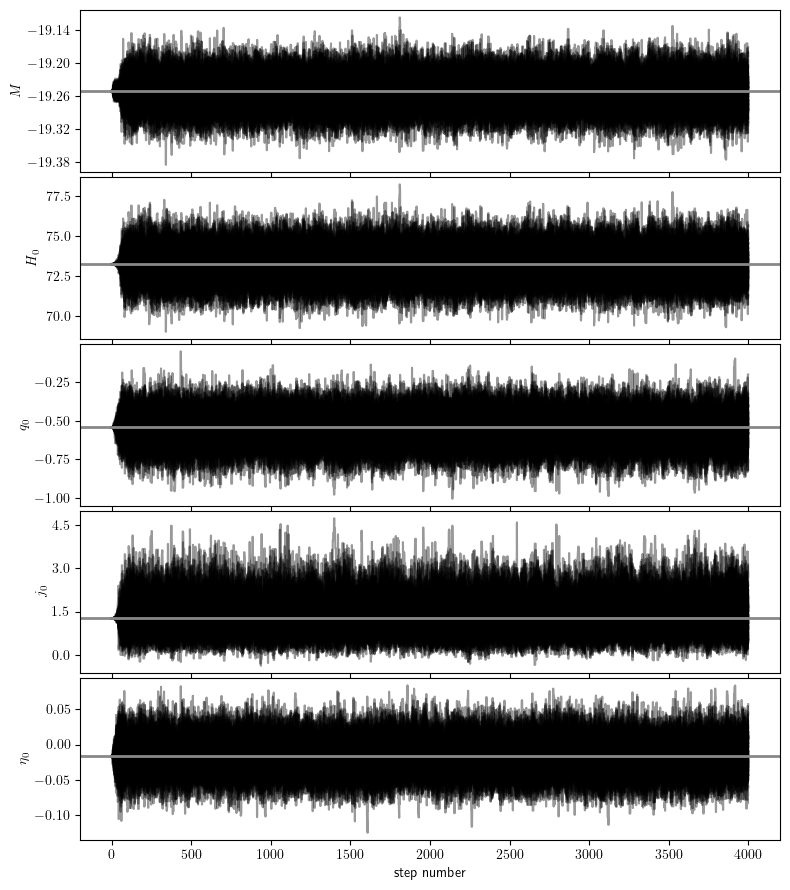

In [39]:
plot_chains(samplerHzPS,par_mlHzPS,parlabtex)

In [40]:
#burnin = 1000
#samplesHz = tira_burnin(samplerHz,burnin,ndim)
samplesHzPS = burninthin(samplerHzPS,tauHzPS)

(15500, 5)


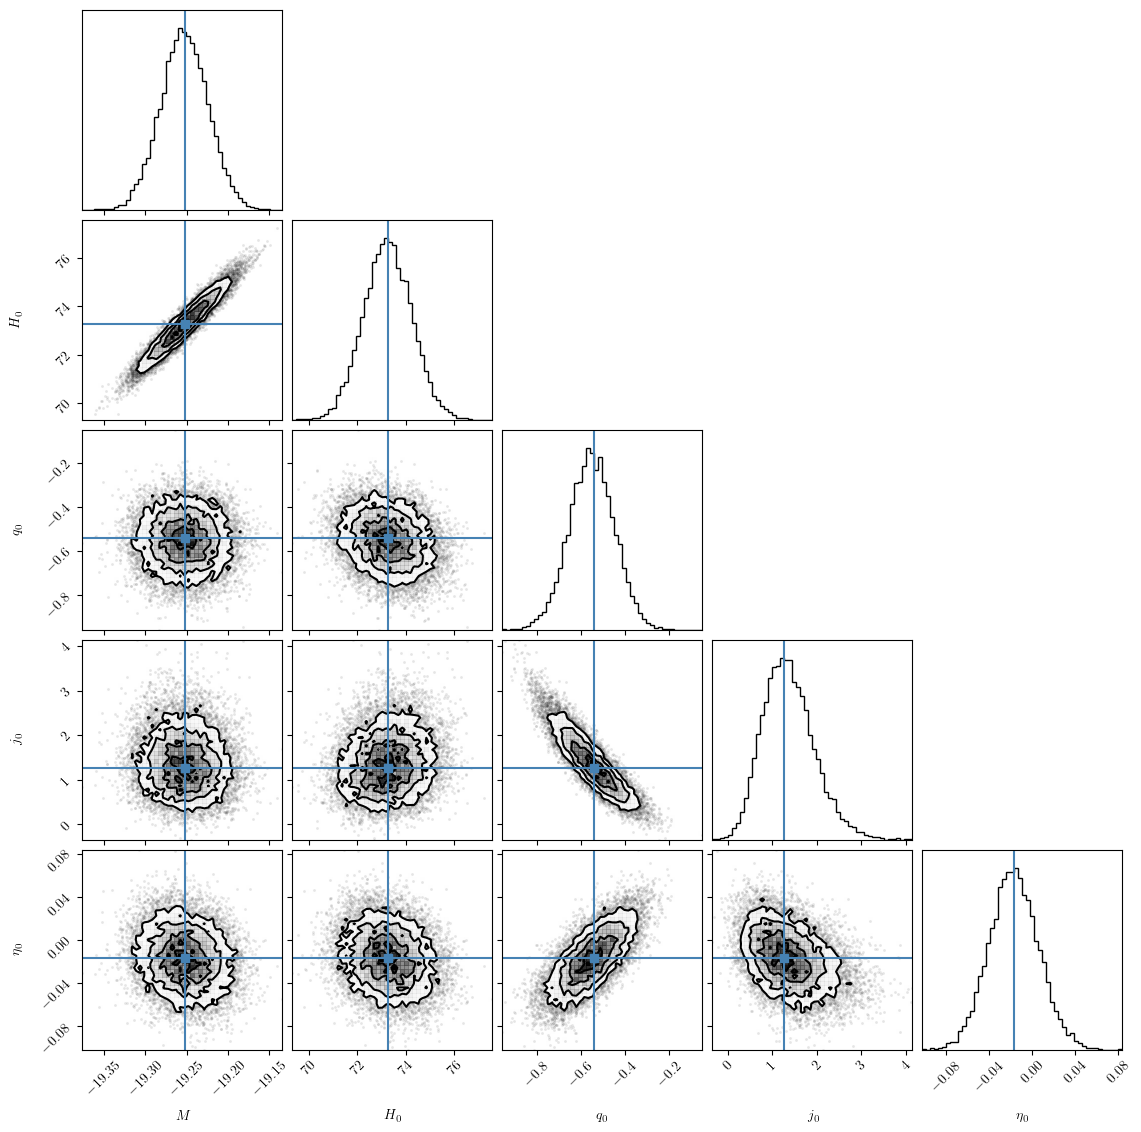

In [41]:
plot_cornertriangle(samplesHzPS,parlabtex,par_mlHzPS)

In [42]:
MC_result(samplesHzPS,par_mlHzPS)

MCMC result:
M = -19.25258 +0.02876 -0.02853 (median: -19.25268, ml: -19.25154)
H0 = 73.26190 +0.99386 -0.99803 (median: 73.25633, ml: 73.26336)
q0 = -0.55130 +0.10268 -0.10114 (median: -0.55188, ml: -0.54145)
j0 = 1.37556 +0.56645 -0.57281 (median: 1.32843, ml: 1.27097)
eta0 = -0.01671 +0.02294 -0.02300 (median: -0.01695, ml: -0.01647)


In [43]:
samplerHzPPlus = run_emcee(par_mlHzPPlus,100,lnprobHzPPlus,2.0,nstepHzPPlus)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [30:08<00:00,  2.21it/s]


Acceptance fraction: [0.501   0.48875 0.50925 0.48925 0.503   0.5115  0.51175 0.497   0.505
 0.4985  0.509   0.51625 0.505   0.4985  0.49125 0.51875 0.49475 0.517
 0.49425 0.49675 0.5085  0.48625 0.4905  0.4795  0.5125  0.50625 0.4965
 0.48725 0.49825 0.49925 0.51025 0.51025 0.49025 0.515   0.5025  0.49425
 0.51075 0.5095  0.51175 0.516   0.5065  0.5065  0.508   0.4985  0.503
 0.501   0.49475 0.51925 0.509   0.494   0.49825 0.4975  0.50825 0.51525
 0.50425 0.48475 0.51175 0.51075 0.505   0.4995  0.51325 0.507   0.50925
 0.51275 0.49075 0.50025 0.505   0.497   0.5005  0.49375 0.495   0.50775
 0.5     0.5085  0.502   0.5105  0.49675 0.51525 0.52175 0.51125 0.50125
 0.505   0.504   0.48775 0.50275 0.49925 0.50575 0.49975 0.4765  0.52425
 0.498   0.5     0.5125  0.5105  0.505   0.49675 0.511   0.49275 0.513
 0.5135 ]
Minimum acceptance: 0.4765
Maximum acceptance: 0.52425


In [44]:
tauHzPPlus = samplerHzPPlus.get_autocorr_time(tol=0)
print(tauHzPPlus)
tauHzPPlusmax = np.amax(tauHzPPlus)
r = nstepHzPPlus/tauHzPPlusmax
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[70.42398198 63.80879072 59.55312034 62.53230893 61.79041361]
56.79883311614611
Convergiu! :)


(13300, 5)


<Figure size 640x480 with 0 Axes>

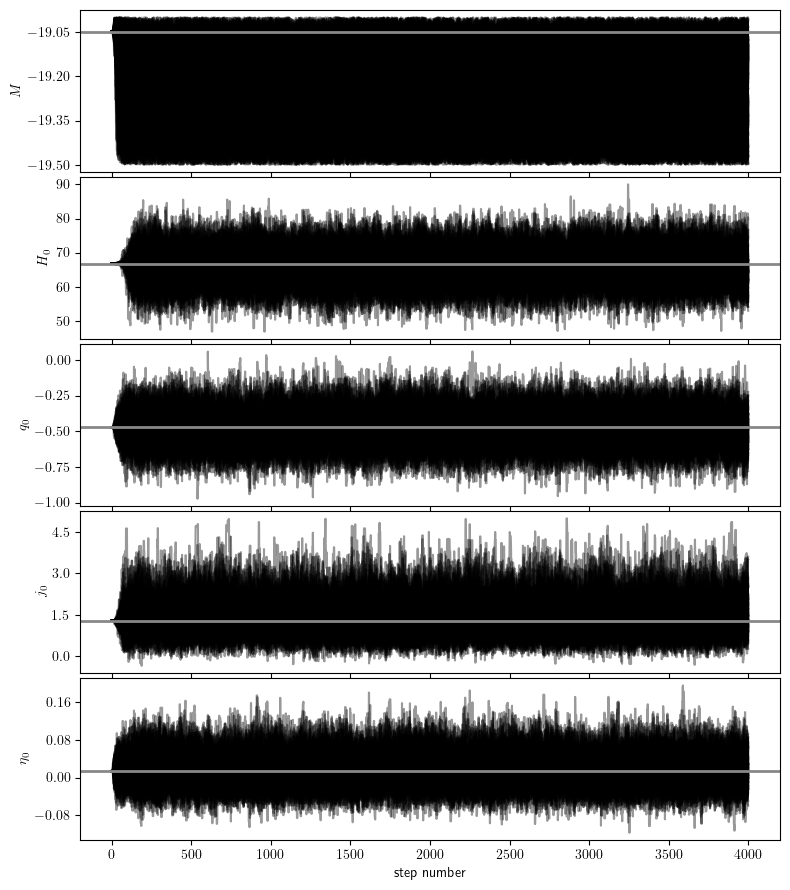

In [45]:
plot_chains(samplerHzPPlus,par_mlHzPPlus,parlabtex)
samplesHzPPlus = burninthin(samplerHzPPlus,tauHzPPlus)

MCMC result:
M = -19.24954 +0.16794 -0.16961 (median: -19.24890, ml: -19.04918)
H0 = 66.15164 +4.92850 -4.88934 (median: 66.16349, ml: 66.69994)
q0 = -0.47855 +0.11751 -0.11673 (median: -0.48051, ml: -0.47151)
j0 = 1.44879 +0.60694 -0.61095 (median: 1.39501, ml: 1.28195)
eta0 = 0.01737 +0.03329 -0.03372 (median: 0.01599, ml: 0.01365)


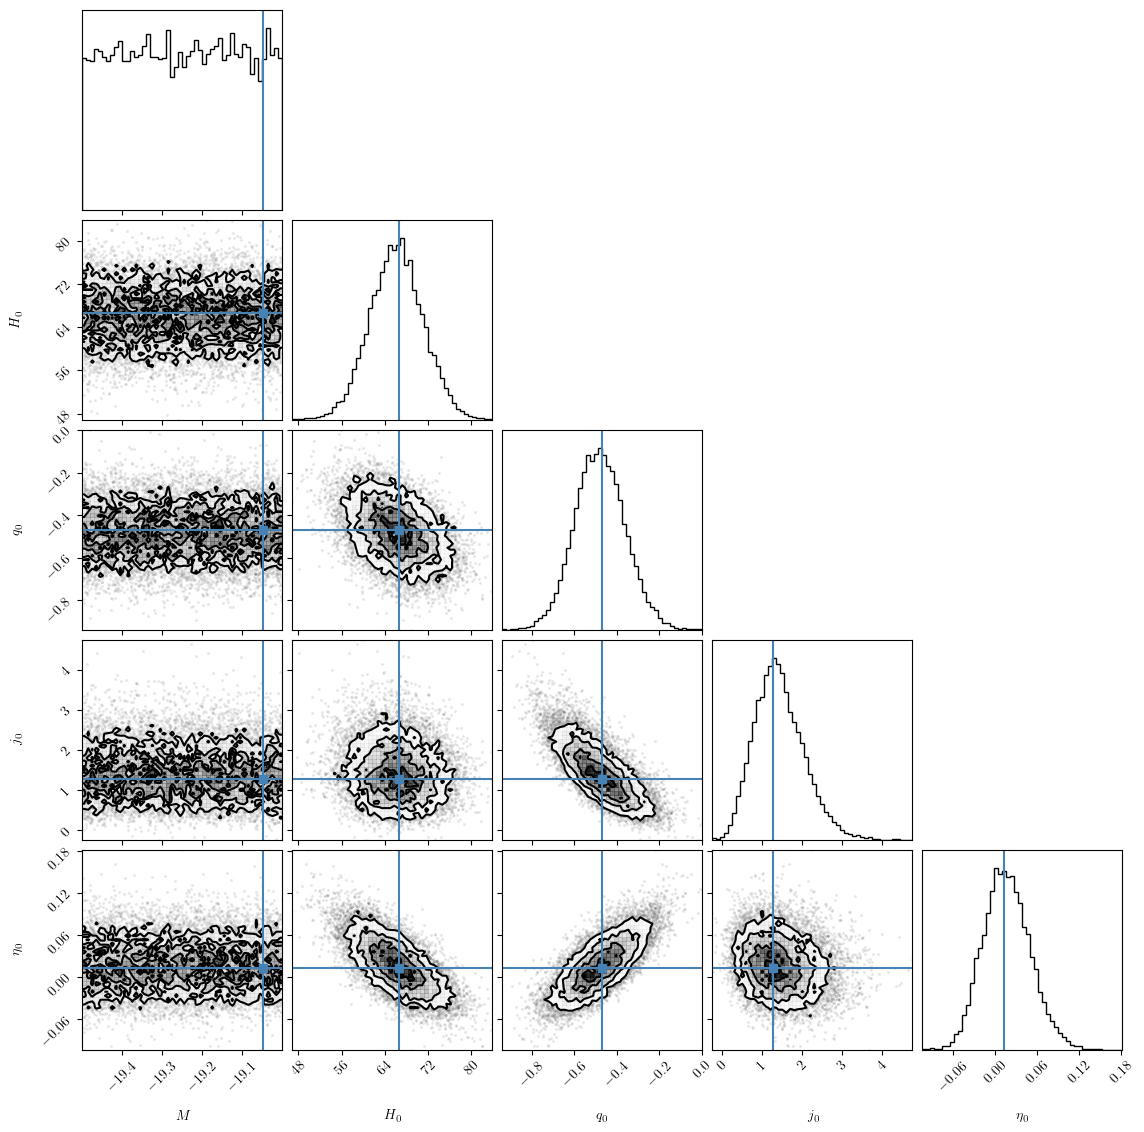

In [46]:
plot_cornertriangle(samplesHzPPlus,parlabtex,par_mlHzPPlus)
MC_result(samplesHzPPlus,par_mlHzPPlus)

In [47]:
samplerHPPB = run_emcee(par_mlHPPB,100,lnprobHPPB,2.0,nstepHPPB)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [35:19<00:00,  1.89it/s]


Acceptance fraction: [0.50175 0.4935  0.50825 0.49325 0.48525 0.488   0.5045  0.52025 0.48475
 0.50525 0.501   0.51175 0.5075  0.49375 0.49925 0.51325 0.5065  0.50475
 0.51    0.503   0.50975 0.49525 0.49875 0.4995  0.49575 0.51425 0.5065
 0.50325 0.49125 0.50875 0.51475 0.5105  0.4955  0.51075 0.481   0.49525
 0.4955  0.50525 0.519   0.5145  0.506   0.48825 0.51475 0.49925 0.50625
 0.50025 0.49975 0.50575 0.5065  0.51    0.4835  0.49925 0.50375 0.4885
 0.51225 0.491   0.50125 0.522   0.50075 0.50275 0.50775 0.50275 0.50275
 0.513   0.48475 0.491   0.5125  0.51375 0.50625 0.49475 0.50275 0.4905
 0.501   0.52725 0.504   0.51125 0.51775 0.4985  0.50625 0.49925 0.4755
 0.4925  0.51575 0.49575 0.509   0.5095  0.49575 0.50875 0.5015  0.5075
 0.5045  0.5005  0.496   0.50675 0.49975 0.50125 0.5015  0.492   0.5055
 0.49975]
Minimum acceptance: 0.4755
Maximum acceptance: 0.52725


In [48]:
tauHPPB = samplerHPPB.get_autocorr_time(tol=0)
print(tauHPPB)
taumaxHPPB = np.amax(tauHPPB)
r = nstepHPPB/taumaxHPPB
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[64.98300548 62.09852128 62.54408232 62.8645596  63.48656265]
61.5545552367609
Convergiu! :)


(12400, 5)


<Figure size 640x480 with 0 Axes>

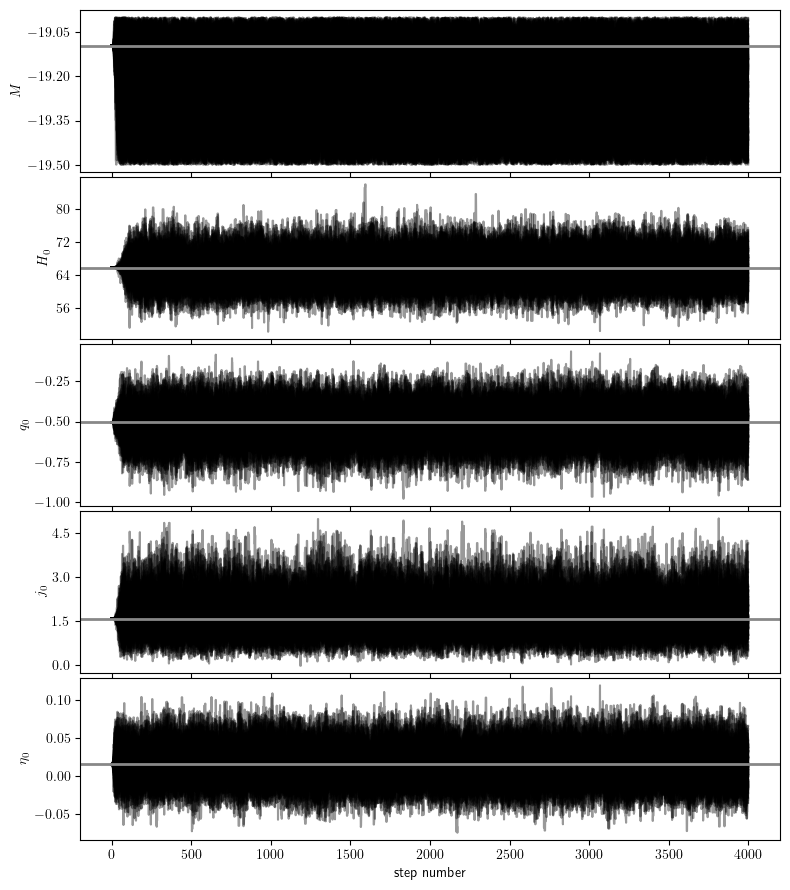

In [49]:
plot_chains(samplerHPPB,par_mlHPPB,parlabtex)
samplesHPPB = burninthin(samplerHPPB,tauHPPB)

MCMC result:
M = -19.24708 +0.17272 -0.17008 (median: -19.24747, ml: -19.09643)
H0 = 65.63849 +3.63770 -3.67919 (median: 65.63283, ml: 65.80186)
q0 = -0.51497 +0.10649 -0.10554 (median: -0.51384, ml: -0.50324)
j0 = 1.71899 +0.60330 -0.61117 (median: 1.66240, ml: 1.58581)
eta0 = 0.01603 +0.02235 -0.02240 (median: 0.01566, ml: 0.01576)


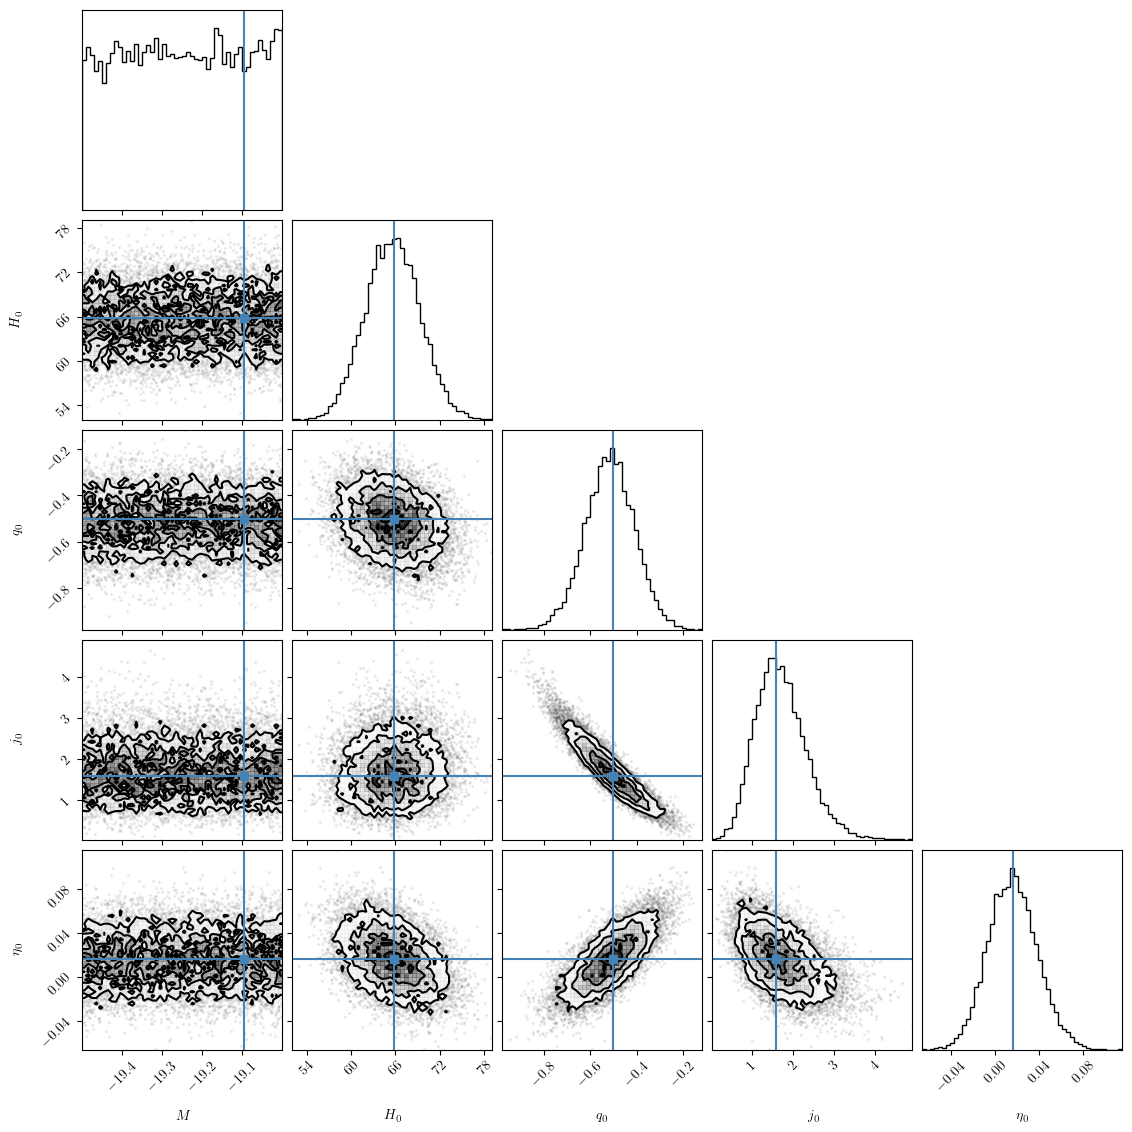

In [50]:
plot_cornertriangle(samplesHPPB,parlabtex,par_mlHPPB)
MC_result(samplesHPPB,par_mlHPPB)

In [51]:
samplerHzBAO = run_emcee(par_mlHzBAO,100,lnprobHzBAO,2.0,nstepHzBAO)

  0%|                                                                                                                                                          | 0/4000 [00:00<?, ?it/s]/home/fernando/anaconda3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:21<00:00, 184.88it/s]

Acceptance fraction: [0.4235  0.3815  0.42075 0.37975 0.39625 0.37625 0.42875 0.40375 0.38275
 0.4055  0.403   0.4055  0.4235  0.42375 0.4115  0.42125 0.41025 0.40675
 0.4305  0.426   0.4275  0.4265  0.405   0.37525 0.411   0.4255  0.40425
 0.42975 0.37325 0.4105  0.42675 0.417   0.39825 0.41225 0.39475 0.41575
 0.414   0.4015  0.4115  0.40575 0.427   0.4075  0.40425 0.419   0.40875
 0.4245  0.41425 0.4275  0.4085  0.4305  0.3965  0.40525 0.42425 0.4205
 0.4105  0.40575 0.39425 0.4125  0.41675 0.41575 0.41625 0.39075 0.3995
 0.40575 0.398   0.41    0.42425 0.42375 0.4335  0.40475 0.39775 0.41075
 0.3975  0.4305  0.398   0.412   0.434   0.4035  0.416   0.41075 0.40075
 0.42475 0.431   0.4105  0.414   0.4235  0.4295  0.4075  0.4055  0.42525
 0.42975 0.397   0.4025  0.4195  0.404   0.40925 0.43125 0.40375 0.42625
 0.389  ]
Minimum acceptance: 0.37325
Maximum acceptance: 0.434


In [52]:
tauHzBAO = samplerHzBAO.get_autocorr_time(tol=0)
print(tauHzBAO)
taumaxHzBAO = np.amax(tauHzBAO)
r = nstepHzBAO/taumaxHzBAO
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[ 86.38759614  77.13941889 105.02040862 104.26829795  93.06795903]
38.08783504477032
Nao convergiu... :(


(9900, 5)


<Figure size 640x480 with 0 Axes>

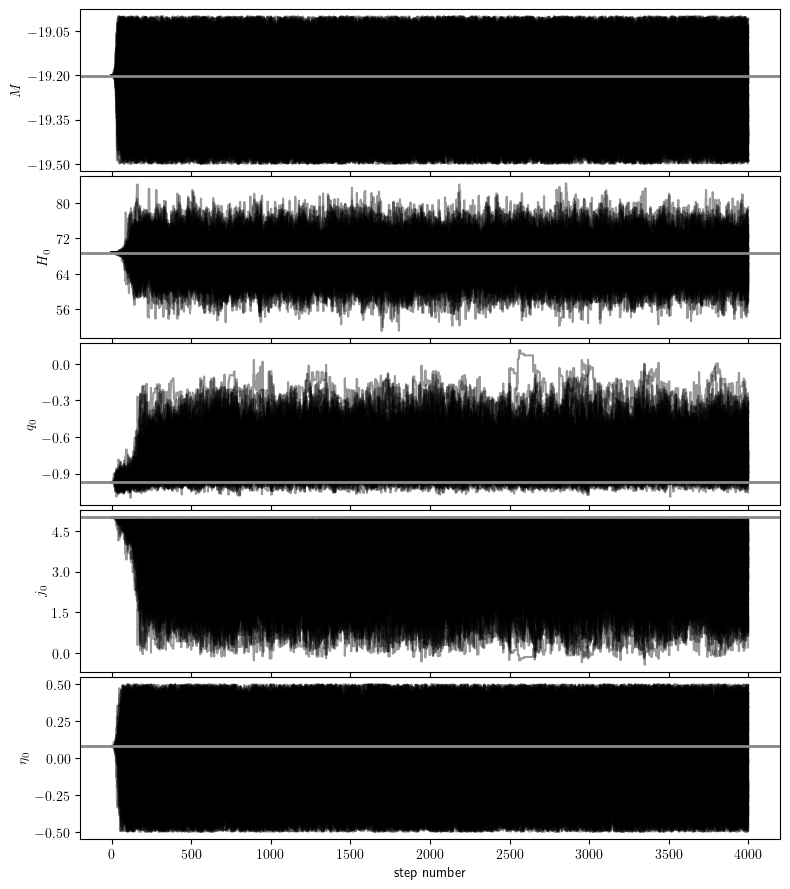

In [53]:
plot_chains(samplerHzBAO,par_mlHzBAO,parlabtex)
samplesHzBAO = burninthin(samplerHzBAO,tauHzBAO)

MCMC result:
M = -19.25012 +0.17213 -0.17010 (median: -19.25095, ml: -19.20147)
H0 = 67.48893 +3.95341 -4.05325 (median: 67.48635, ml: 68.78319)
q0 = -0.75993 +0.17633 -0.16467 (median: -0.79711, ml: -0.97241)
j0 = 3.35628 +1.22684 -1.29588 (median: 3.54411, ml: 5.00000)
eta0 = 0.00521 +0.33581 -0.34143 (median: 0.00950, ml: 0.07868)


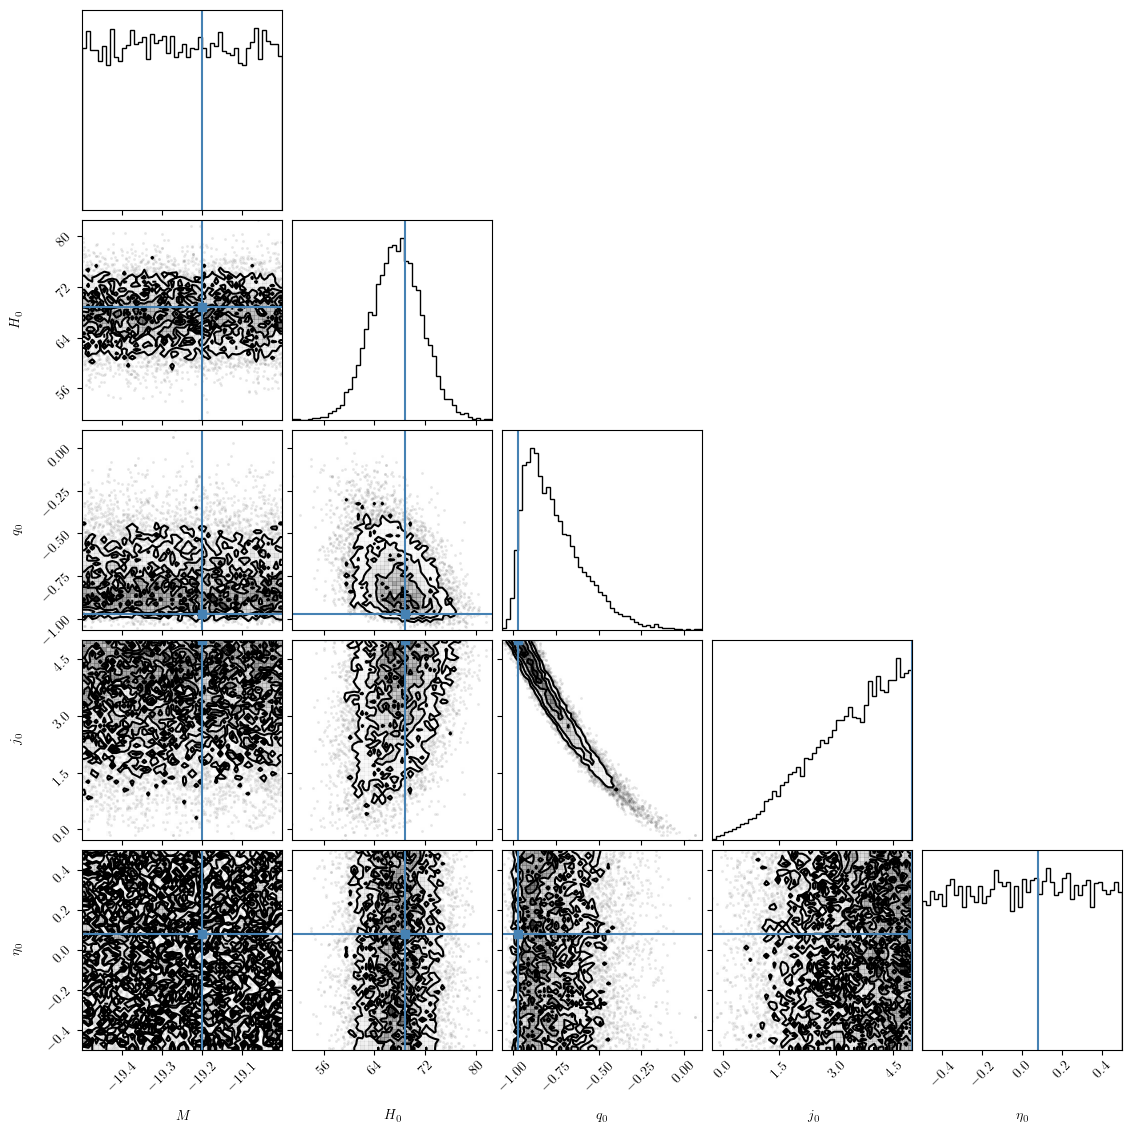

In [54]:
plot_cornertriangle(samplesHzBAO,parlabtex,par_mlHzBAO)
MC_result(samplesHzBAO,par_mlHzBAO)

In [55]:
sampler = run_emcee(par_ml,100,lnprob,2.0,nstep)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [32:51<00:00,  2.03it/s]

Acceptance fraction: [0.5505  0.53    0.53825 0.54875 0.5315  0.52925 0.5505  0.55225 0.546
 0.55225 0.5495  0.55225 0.55    0.55    0.5605  0.5555  0.5495  0.5495
 0.54625 0.5445  0.55375 0.54975 0.55025 0.5395  0.5545  0.5625  0.546
 0.54825 0.53525 0.5565  0.54575 0.5455  0.5375  0.5565  0.528   0.5405
 0.5405  0.53775 0.5475  0.5475  0.5505  0.549   0.55325 0.55625 0.53575
 0.538   0.54975 0.5545  0.549   0.539   0.53275 0.5445  0.54575 0.535
 0.5455  0.527   0.54975 0.5485  0.54275 0.54025 0.561   0.548   0.5465
 0.55825 0.535   0.557   0.55375 0.55475 0.54675 0.53225 0.54975 0.5485
 0.535   0.5495  0.5615  0.55125 0.53625 0.5415  0.55975 0.549   0.53725
 0.54975 0.55025 0.542   0.54675 0.552   0.553   0.554   0.5425  0.555
 0.54675 0.53275 0.54175 0.53375 0.543   0.55025 0.541   0.54475 0.53375
 0.5495 ]
Minimum acceptance: 0.527
Maximum acceptance: 0.5625


In [56]:
tau = sampler.get_autocorr_time(tol=0)
print(tau)
taumax = np.amax(tau)
r = nstep/taumax
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[52.99203963 52.52461638 54.05889829 56.09843151 50.95910557]
71.30324132584634
Convergiu! :)


(15500, 5)


<Figure size 640x480 with 0 Axes>

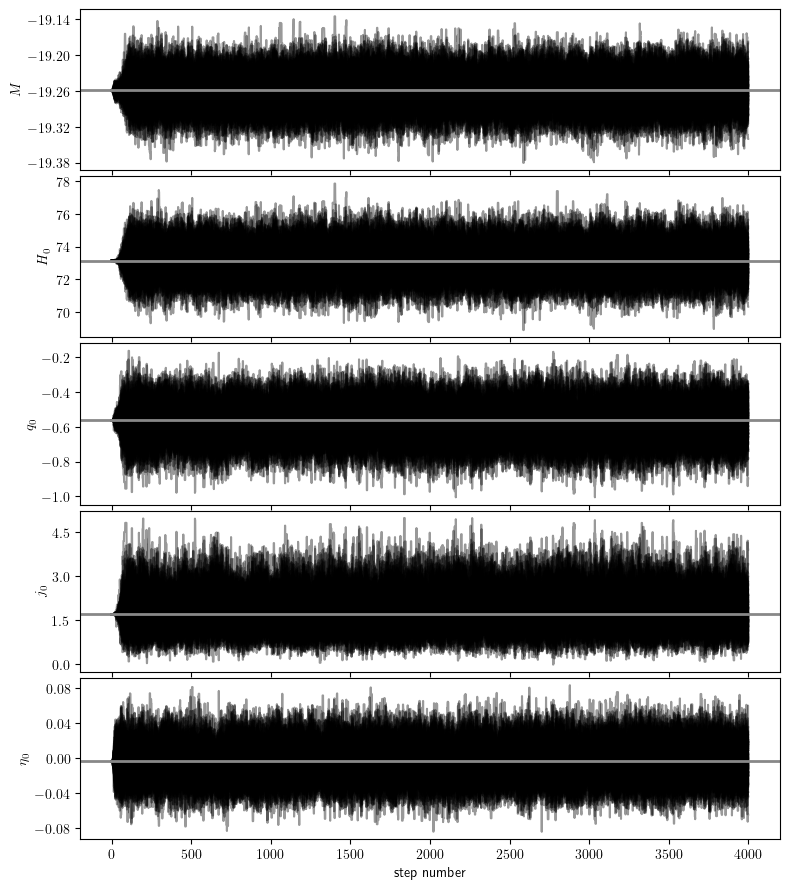

In [57]:
plot_chains(sampler,par_ml,parlabtex)
samples = burninthin(sampler,tau)

MCMC result:
M = -19.25981 +0.02842 -0.02809 (median: -19.26009, ml: -19.25910)
H0 = 73.12862 +0.99112 -0.97504 (median: 73.11641, ml: 73.11729)
q0 = -0.57440 +0.10237 -0.10255 (median: -0.57384, ml: -0.56200)
j0 = 1.83827 +0.61544 -0.61709 (median: 1.78960, ml: 1.70521)
eta0 = -0.00412 +0.01984 -0.01982 (median: -0.00439, ml: -0.00382)


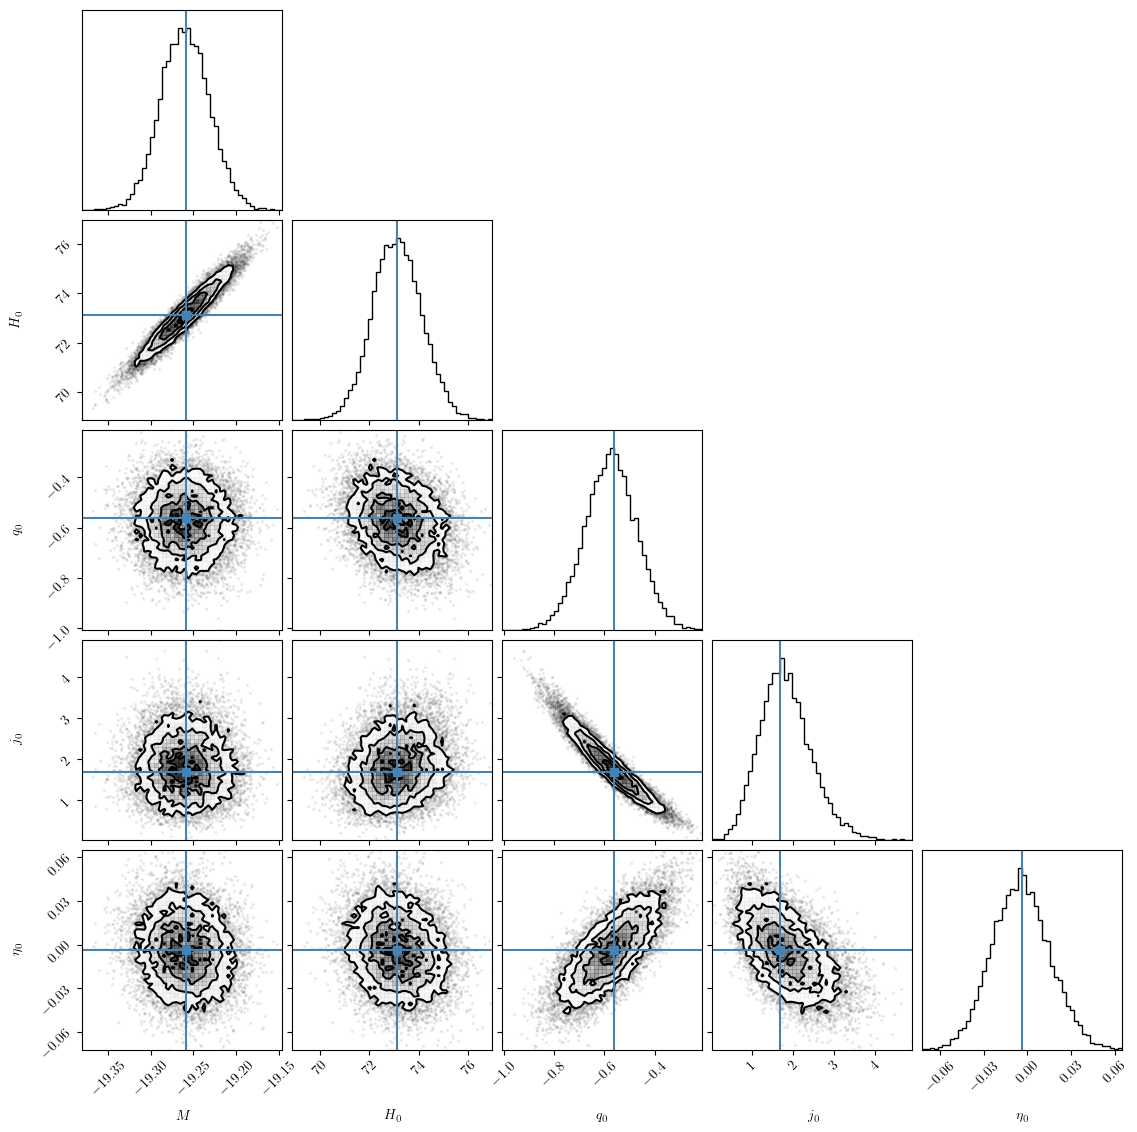

In [58]:
plot_cornertriangle(samples,parlabtex,par_ml)
MC_result(samples,par_ml)

In [59]:
print(par_ml)
print(-2*lnprob(par_ml))
print(-2*lnprob([-19.24593, 40.11681, 0.70867, 2.25014, 0.46564]))

[-1.92590992e+01  7.31172916e+01 -5.61997256e-01  1.70520866e+00
 -3.81814807e-03]
1492.3036844341468
119867.78636785544


In [60]:
from getdist import plots, MCSamples
import getdist, IPython
print('Version: ',getdist.__version__)

Version:  1.5.1


In [61]:
gsamples = MCSamples(samples=samples,names=parnames,labels=parlabels)
gsamples.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})
gsamplesHPPB = MCSamples(samples=samplesHPPB,names=parnames,labels=parlabels)
gsamplesHPPB.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})
gsamplesHzPS = MCSamples(samples=samplesHzPS,names=parnames,labels=parlabels)
gsamplesHzPS.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})
gsamplesHzBAO = MCSamples(samples=samplesHzBAO,names=parnames,labels=parlabels)
gsamplesHzBAO.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})
gsamplesHzPPlus = MCSamples(samples=samplesHzPPlus,names=parnames,labels=parlabels)
gsamplesHzPPlus.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


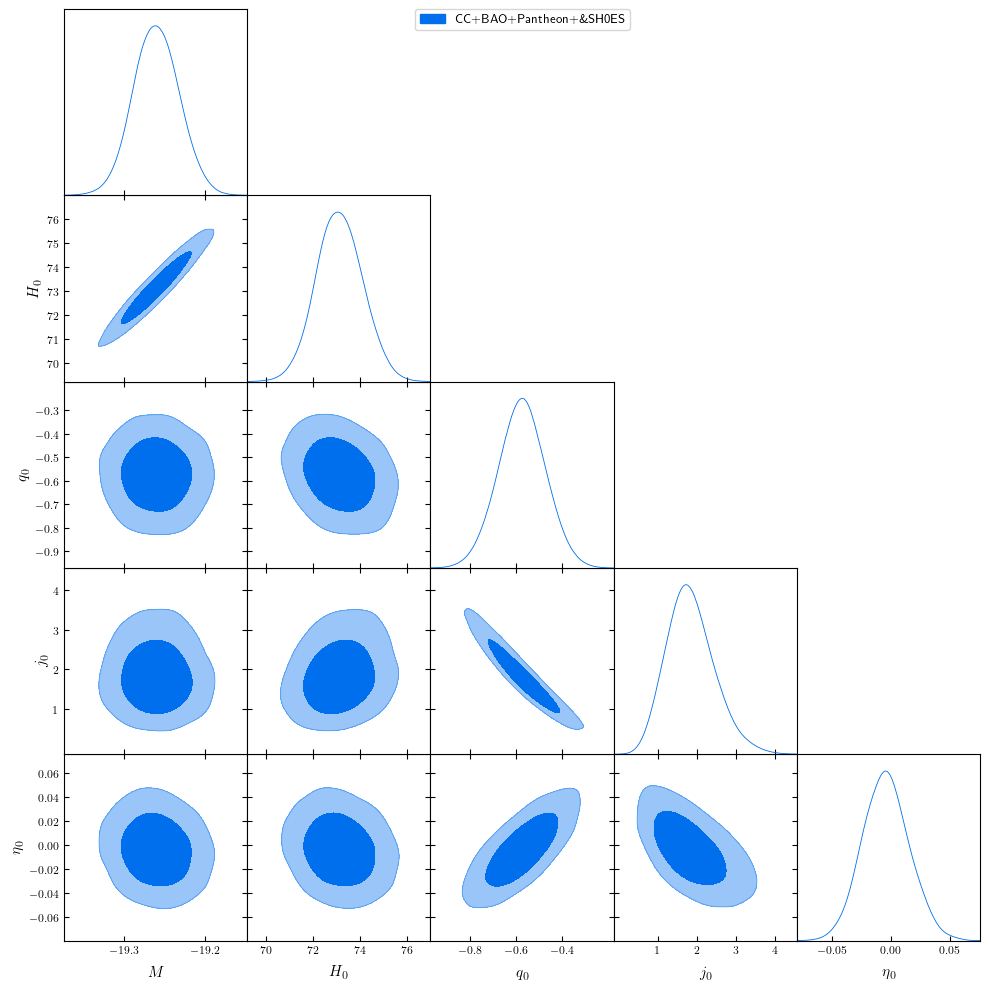

In [62]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamples], filled=True,legend_labels=[r'CC+BAO+Pantheon+\&SH0ES'])
#g.export('fig/g'+prefix+'All-triangle.pdf')

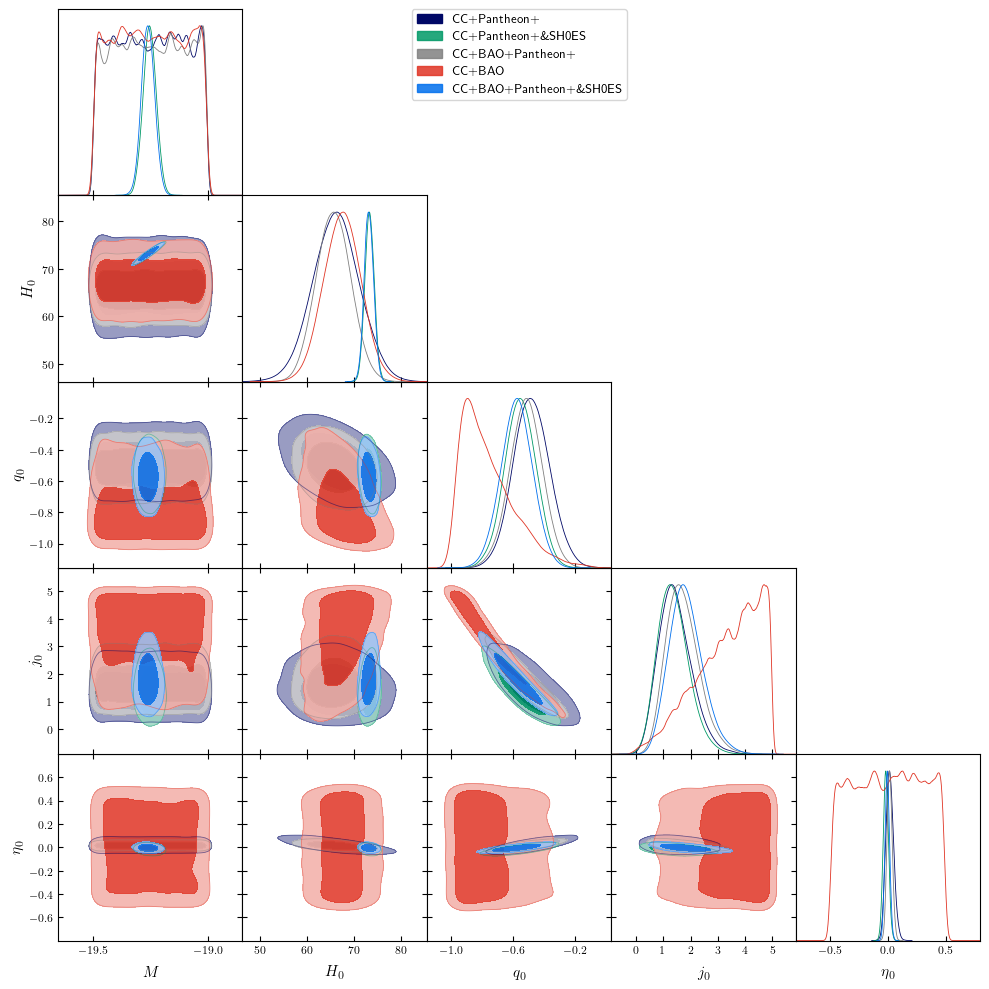

In [63]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamplesHzPPlus,gsamplesHzPS,gsamplesHPPB,gsamplesHzBAO,gsamples], filled=True,\
legend_labels=['CC+Pantheon+',r'CC+Pantheon+\&SH0ES','CC+BAO+Pantheon+','CC+BAO',r'CC+BAO+Pantheon+\&SH0ES'])
#g.export('fig/g'+prefix+'All-triangle.pdf')

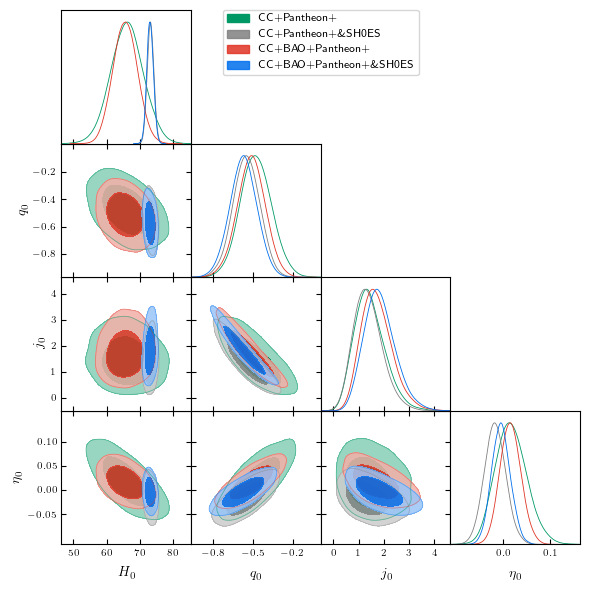

In [89]:
g = plots.getSubplotPlotter(width_inch=6)
g.triangle_plot([gsamplesHzPPlus,gsamplesHzPS,gsamplesHPPB,gsamples], ['H0', 'q0', 'j0', 'eta0'], filled=True,\
legend_labels=['CC+Pantheon+',r'CC+Pantheon+\&SH0ES','CC+BAO+Pantheon+',r'CC+BAO+Pantheon+\&SH0ES'])
g.export('fig/g'+prefix+'All-triangle6.pdf')

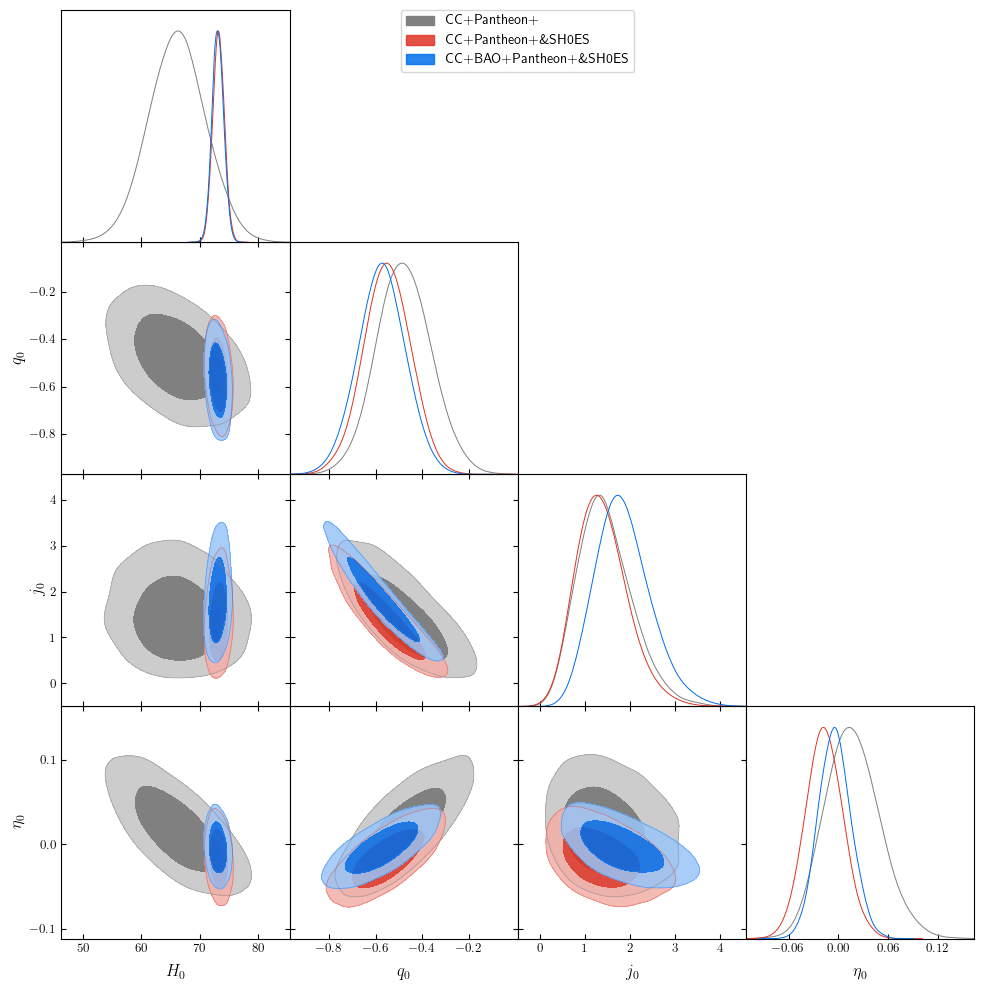

In [65]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamplesHzPPlus,gsamplesHzPS,gsamples], ['H0', 'q0', 'j0', 'eta0'], filled=True,\
legend_labels=['CC+Pantheon+',r'CC+Pantheon+\&SH0ES',r'CC+BAO+Pantheon+\&SH0ES'])
g.export('fig/g'+prefix+'2All-triangle.pdf')

<>:2: SyntaxWarning: invalid escape sequence '\&'
<>:2: SyntaxWarning: invalid escape sequence '\&'
/tmp/ipykernel_13526/1873928514.py:2: SyntaxWarning: invalid escape sequence '\&'
  g.triangle_plot([gsamples], filled=True, legend_labels=['CC+BAO+Pantheon+\&SH0ES'])


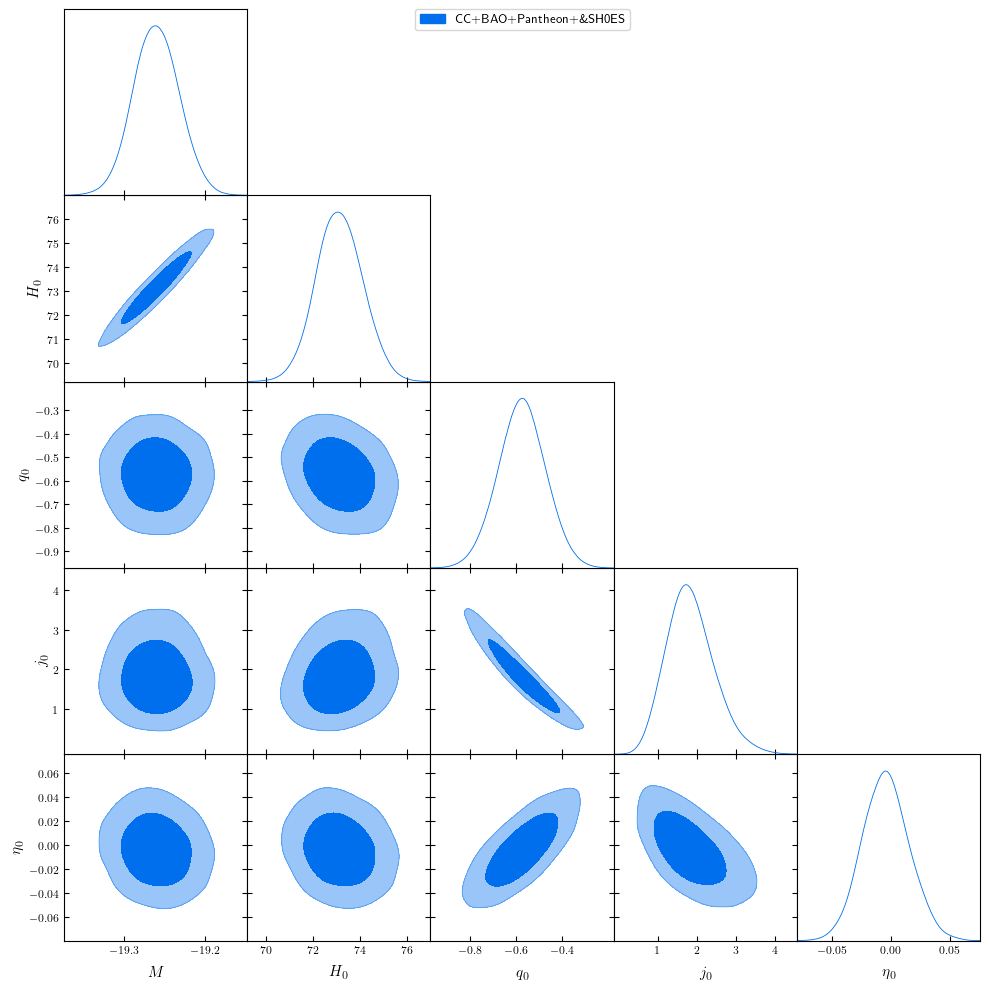

In [66]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamples], filled=True, legend_labels=['CC+BAO+Pantheon+\&SH0ES'])
#g.export('fig/g'+prefix+'-triangle.pdf')

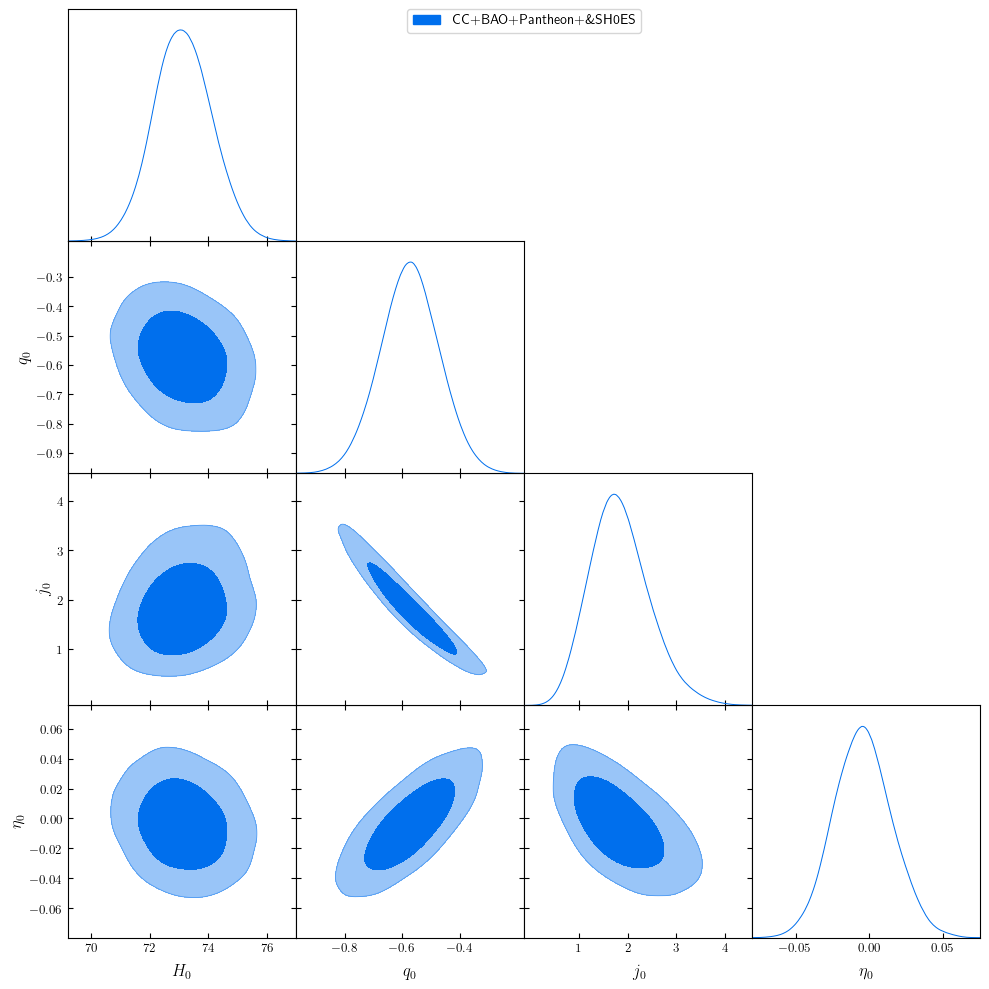

In [67]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamples], ['H0', 'q0', 'j0', 'eta0'], filled=True, legend_labels=[r'CC+BAO+Pantheon+\&SH0ES'])
g.export('fig/g'+prefix+'-triangle.pdf')

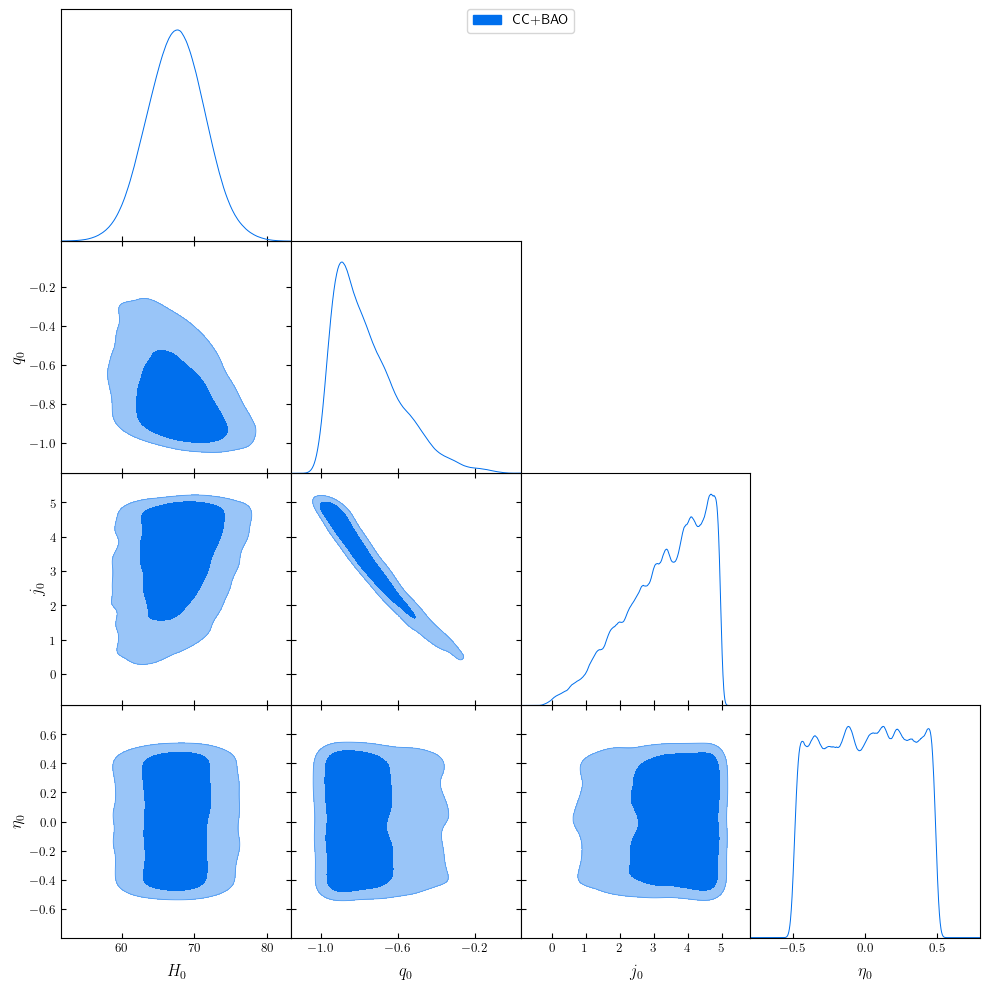

In [68]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamplesHzBAO], ['H0', 'q0', 'j0', 'eta0'], filled=True, legend_labels=['CC+BAO'])
#g.export('fig/g'+prefix+'-triangle.pdf')

In [69]:
for i in range(len(par0)):
    for j in range(1,4):
        print(gsamplesHzBAO.getInlineLatex(parnames[i],limit=j))
        
print(gsamplesHzBAO.getTable().tableTex())#[68.0,0.645,0.60,1.736,0.231]

M = -19.25\pm 0.14
M = -19.25^{+0.24}_{-0.24}
M = -19.25^{+0.25}_{-0.25}
H_0 = 67.5\pm 4.0
H_0 = 67^{+8}_{-8}
H_0 = 67^{+10}_{-10}
q_0 = -0.760^{+0.085}_{-0.21}
q_0 = -0.76^{+0.36}_{-0.26}
q_0 = -0.76^{+0.66}_{-0.28}
j_0 = 3.36^{+1.6}_{-0.68}
j_0 = 3.4^{+1.7}_{-2.2}
j_0 = 3.4^{+1.7}_{-3.3}
\eta_0 = 0.01\pm 0.29
\eta_0 = 0.01^{+0.47}_{-0.47}
\eta_0 = 0.01^{+0.49}_{-0.50}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.25^{+0.24}_{-0.24}    $\\

{\boldmath$H_0            $} & $67^{+8}_{-8}              $\\

{\boldmath$q_0            $} & $-0.76^{+0.36}_{-0.26}     $\\

{\boldmath$j_0            $} & $3.4^{+1.7}_{-2.2}         $\\

{\boldmath$\eta_0         $} & $0.01^{+0.47}_{-0.47}      $\\
\hline
\end{tabular}


In [70]:
for i in range(len(par0)):
    for j in range(1,4):
        print(gsamplesHzPPlus.getInlineLatex(parnames[i],limit=j))
        
print(gsamplesHzPPlus.getTable().tableTex())#[68.0,0.645,0.60,1.736,0.231]

M = -19.25\pm 0.14
M = -19.25^{+0.24}_{-0.24}
M = -19.25^{+0.25}_{-0.25}
H_0 = 66.2\pm 5.0
H_0 = 66^{+10}_{-10}
H_0 = 66^{+10}_{-20}
q_0 = -0.48\pm 0.12
q_0 = -0.48^{+0.24}_{-0.23}
q_0 = -0.48^{+0.38}_{-0.35}
j_0 = 1.45^{+0.49}_{-0.70}
j_0 = 1.4^{+1.3}_{-1.1}
j_0 = 1.4^{+2.3}_{-1.4}
\eta_0 = 0.017^{+0.031}_{-0.036}
\eta_0 = 0.017^{+0.071}_{-0.062}
\eta_0 = 0.017^{+0.11}_{-0.098}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.25^{+0.24}_{-0.24}    $\\

{\boldmath$H_0            $} & $66^{+10}_{-10}            $\\

{\boldmath$q_0            $} & $-0.48^{+0.24}_{-0.23}     $\\

{\boldmath$j_0            $} & $1.4^{+1.3}_{-1.1}         $\\

{\boldmath$\eta_0         $} & $0.017^{+0.071}_{-0.062}   $\\
\hline
\end{tabular}


In [71]:
for i in range(len(par0)):
    for j in range(1,4):
        print(gsamplesHzPS.getInlineLatex(parnames[i],limit=j))
        
print(gsamplesHzPS.getTable().tableTex())#[68.0,0.645,0.60,1.736,0.231]

M = -19.253\pm 0.029
M = -19.253^{+0.057}_{-0.057}
M = -19.253^{+0.086}_{-0.083}
H_0 = 73.26\pm 0.99
H_0 = 73.3^{+2.0}_{-2.0}
H_0 = 73.3^{+3.0}_{-3.0}
q_0 = -0.55\pm 0.10
q_0 = -0.55^{+0.20}_{-0.21}
q_0 = -0.55^{+0.31}_{-0.31}
j_0 = 1.38^{+0.47}_{-0.65}
j_0 = 1.4^{+1.2}_{-1.1}
j_0 = 1.4^{+2.1}_{-1.4}
\eta_0 = -0.017\pm 0.023
\eta_0 = -0.017^{+0.047}_{-0.046}
\eta_0 = -0.017^{+0.072}_{-0.068}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.253^{+0.057}_{-0.057} $\\

{\boldmath$H_0            $} & $73.3^{+2.0}_{-2.0}        $\\

{\boldmath$q_0            $} & $-0.55^{+0.20}_{-0.21}     $\\

{\boldmath$j_0            $} & $1.4^{+1.2}_{-1.1}         $\\

{\boldmath$\eta_0         $} & $-0.017^{+0.047}_{-0.046}  $\\
\hline
\end{tabular}


In [72]:
for i in range(len(par0)):
    for j in range(1,4):
        print(gsamplesHPPB.getInlineLatex(parnames[i],limit=j))
        
print(gsamplesHPPB.getTable().tableTex())#[68.0,0.645,0.60,1.736,0.231]

M = -19.25\pm 0.14
M = -19.25^{+0.24}_{-0.24}
M = -19.25^{+0.25}_{-0.26}
H_0 = 65.6\pm 3.7
H_0 = 66^{+7}_{-7}
H_0 = 66^{+10}_{-10}
q_0 = -0.51\pm 0.11
q_0 = -0.51^{+0.21}_{-0.22}
q_0 = -0.51^{+0.31}_{-0.34}
j_0 = 1.72^{+0.49}_{-0.70}
j_0 = 1.7^{+1.3}_{-1.2}
j_0 = 1.7^{+2.4}_{-1.4}
\eta_0 = 0.016\pm 0.022
\eta_0 = 0.016^{+0.047}_{-0.043}
\eta_0 = 0.016^{+0.069}_{-0.067}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.25^{+0.24}_{-0.24}    $\\

{\boldmath$H_0            $} & $66^{+7}_{-7}              $\\

{\boldmath$q_0            $} & $-0.51^{+0.21}_{-0.22}     $\\

{\boldmath$j_0            $} & $1.7^{+1.3}_{-1.2}         $\\

{\boldmath$\eta_0         $} & $0.016^{+0.047}_{-0.043}   $\\
\hline
\end{tabular}


In [73]:
for i in range(len(par0)):
    for j in range(1,4):
        print(gsamples.getInlineLatex(parnames[i],limit=j))
        
print(gsamples.getTable().tableTex())#[68.0,0.645,0.60,1.736,0.231]

M = -19.260\pm 0.028
M = -19.260^{+0.057}_{-0.057}
M = -19.260^{+0.087}_{-0.088}
H_0 = 73.13\pm 0.99
H_0 = 73.1^{+2.0}_{-2.0}
H_0 = 73.1^{+3.0}_{-3.0}
q_0 = -0.57\pm 0.10
q_0 = -0.57^{+0.21}_{-0.21}
q_0 = -0.57^{+0.31}_{-0.31}
j_0 = 1.84^{+0.52}_{-0.69}
j_0 = 1.8^{+1.3}_{-1.2}
j_0 = 1.8^{+2.2}_{-1.5}
\eta_0 = -0.004^{+0.019}_{-0.021}
\eta_0 = -0.004^{+0.041}_{-0.039}
\eta_0 = -0.004^{+0.063}_{-0.057}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.260^{+0.057}_{-0.057} $\\

{\boldmath$H_0            $} & $73.1^{+2.0}_{-2.0}        $\\

{\boldmath$q_0            $} & $-0.57^{+0.21}_{-0.21}     $\\

{\boldmath$j_0            $} & $1.8^{+1.3}_{-1.2}         $\\

{\boldmath$\eta_0         $} & $-0.004^{+0.041}_{-0.039}  $\\
\hline
\end{tabular}


In [74]:
print(np.shape(samples))
print(parnames)

(15500, 5)
['M', 'H0', 'q0', 'j0', 'eta0']


In [75]:
def jz(z,par):
    M, H0, q0, j0, eta0 = par
    return (-3*(18 + 18*(2 + 3*j0)*z + 9*(4 + 7*j0 + 2*j0**2)*z**2 + (14 + 21*j0 + 9*j0**2 + 2*j0**3)*z**3 - 27*q0**6*z**3 - \
            9*q0**5*z**2*(9 + 7*z) + 3*q0**4*(-12 - 60*z - 57*z**2 + 4*(-5 + 3*j0)*z**3) + \
            q0**3*(90 + 342*z + 9*(41 + 9*j0)*z**2 + (121 + 57*j0)*z**3) - \
            3*q0*(6 + 6*(5 + 6*j0)*z + (42 + 51*j0 + 6*j0**2)*z**2 + (18 + 19*j0 + 4*j0**2)*z**3) - \
            3*q0**2*(18 - 18*(-2 + j0)*z - 3*(-3 + j0)*z**2 + (-5 + j0 + 5*j0**2)*z**3))* \
          (27*q0**6*z**3 + 9*q0**5*z**2*(9 + 7*z) + q0**4*(54 + 216*z + 189*z**2 + (60 - 36*j0)*z**3) - \
            q0**3*(162 + 486*z + 9*(49 + 9*j0)*z**2 + (121 + 57*j0)*z**3) + \
            3*q0*(-18 + 18*(-1 + 2*j0)*z + 3*(6 + 17*j0 + 2*j0**2)*z**2 + (18 + 19*j0 + 4*j0**2)*z**3) + \
            3*q0**2*(54 - 18*(-6 + j0)*z - 3*(-15 + j0)*z**2 + (-5 + j0 + 5*j0**2)*z**3) - \
            z*(2*j0**3*z**2 + 9*j0**2*z*(2 + z) + 2*z*(9 + 7*z) + 3*j0*(18 + 21*z + 7*z**2))) + \
         54*(-1 + q0)**4*(1 + z)**2*(-54*q0*(1 + z)**3 + 2*j0**3*z**2*(3 + z) - 27*q0**6*z**2*(3 + z) + \
            3*q0**2*z*(18 + 15*z + 5*z**2) + 2*z*(18 + 21*z + 7*z**2) - 9*q0**5*z*(18 + 21*z + 7*z**2) - \
            6*q0**4*(18 + 27*z + 30*z**2 + 10*z**3) + q0**3*(162 + 396*z + 363*z**2 + 121*z**3) - \
            3*j0**2*z*(5*q0**2*z*(3 + z) + 4*q0*(3 + 3*z + z**2) - 3*(4 + 3*z + z**2)) + \
            3*j0*(18 + 24*z + 21*z**2 + 7*z**3 + 12*q0**4*z**2*(3 + z) + q0**3*z*(54 + 57*z + 19*z**2) - \
               q0**2*(-18 + 12*z + 3*z**2 + z**3) - q0*(36 + 66*z + 57*z**2 + 19*z**3))))/ \
       ((3 + z + j0*z - 3*q0**2*z - q0*(3 + z))**2* \
         (18 + 6*(5 + 2*j0)*z + (14 + 7*j0 + 2*j0**2)*z**2 + 9*q0**4*z**2 + 18*q0**3*z*(1 + z) - \
            2*q0*(6 + 5*z)*(3 + (4 + j0)*z) + q0**2*(18 + 30*z + (17 - 9*j0)*z**2))**2)

In [76]:
def jzsamp(z,samples):
    nsamp = len(samples)
    W = np.zeros(nsamp)
    for j in range(nsamp):
        par = samples[j]
        W[j] = jz(z,par)
    W = np.sort(W)
    W50 = W[50 * int(nsamp/100)]
    W16 = W[16 * int(nsamp/100)]
    W84 = W[84 * int(nsamp/100)]
    W2_5 = W[25 * int(nsamp/1000)]
    W97_5 = W[975 * int(nsamp/1000)]
    return [z,W50,W16,W84,W2_5,W97_5]

In [77]:
nz = 100
zvec = np.linspace(0,3,nz)

In [78]:
jzmat = []
for i in range(nz):
    jzmat.append(jzsamp(zvec[i],samples))

In [79]:
jzmat = np.array(jzmat)
print(np.shape(jzmat))

(100, 6)


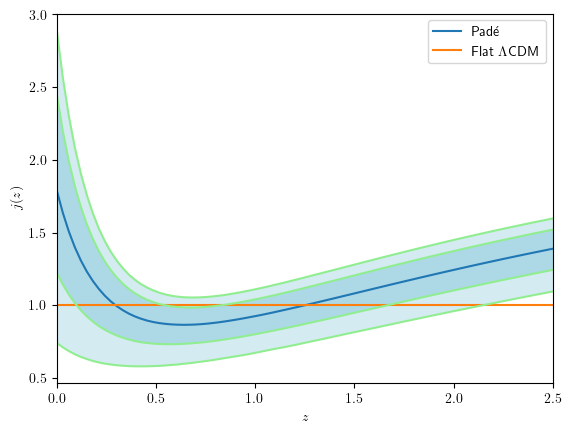

In [80]:
#plt.figure(figsize=(4.3,3.2))
pl.plot(zvec,jzmat[:,1],label='Padé')
pl.plot(zvec,np.ones_like(zvec),label=r'Flat $\Lambda$CDM')
pl.fill_between(zvec,jzmat[:,4],jzmat[:,5], facecolor='lightblue',alpha=.5)
pl.fill_between(zvec,jzmat[:,2],jzmat[:,3],facecolor='lightblue')
pl.plot(zvec,jzmat[:,2],color='lightgreen')
pl.plot(zvec,jzmat[:,3],color='lightgreen')
pl.plot(zvec,jzmat[:,4],color='lightgreen')
pl.plot(zvec,jzmat[:,5],color='lightgreen')
#pl.plot(zvec, np.zeros_like(zvec), color='k',ls='--', linewidth=0.5)
pl.xlabel('$z$')
pl.ylabel('$j(z)$')
pl.xlim(0,2.5)
#pl.ylim(0,5)
pl.legend()
pl.savefig('./fig/jz'+prefix+'.pdf')
pl.show()

In [81]:
np.savetxt('./data/jz'+prefix+'.txt',jzmat)

In [82]:
def fzsamp(f,z,samples):
    nsamp = len(samples)
    W = np.zeros(nsamp)
    for j in range(nsamp):
        par = samples[j]
        W[j] = f(z,par)
    W = np.sort(W)
    W50 = W[50 * int(nsamp/100)]
    W16 = W[16 * int(nsamp/100)]
    W84 = W[84 * int(nsamp/100)]
    W2_5 = W[25 * int(nsamp/1000)]
    W97_5 = W[975 * int(nsamp/1000)]
    return [z,W50,W16,W84,W2_5,W97_5]

In [83]:
def Hz(z,theta):
    M, H0, q0, j0, eta0 = theta
    return H0*Ez(z,theta)

Hzmat = []
for i in range(nz):
    Hzmat.append(fzsamp(Hz,zvec[i],samples))

Hzmat = np.array(Hzmat)
print(np.shape(Hzmat))

np.savetxt('./data/Hz'+prefix+'.txt',Hzmat)

(100, 6)


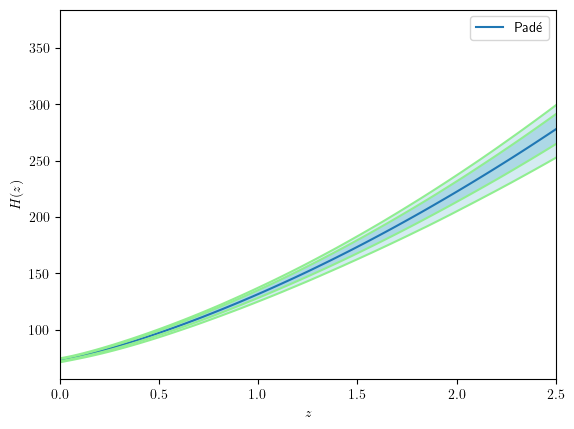

In [84]:
#plt.figure(figsize=(4.3,3.2))
pl.plot(zvec,Hzmat[:,1],label='Padé')
#pl.plot(zvec,np.ones_like(zvec),label=r'Flat $\Lambda$CDM')
pl.fill_between(zvec,Hzmat[:,4],Hzmat[:,5], facecolor='lightblue',alpha=.5)
pl.fill_between(zvec,Hzmat[:,2],Hzmat[:,3],facecolor='lightblue')
pl.plot(zvec,Hzmat[:,2],color='lightgreen')
pl.plot(zvec,Hzmat[:,3],color='lightgreen')
pl.plot(zvec,Hzmat[:,4],color='lightgreen')
pl.plot(zvec,Hzmat[:,5],color='lightgreen')
#pl.plot(zvec, np.zeros_like(zvec), color='k',ls='--', linewidth=0.5)
pl.xlabel('$z$')
pl.ylabel('$H(z)$')
pl.xlim(0,2.5)
#pl.ylim(0,5)
pl.legend()
pl.savefig('./fig/Hz'+prefix+'.pdf')
pl.show()

In [85]:
def qz(z,theta):
    M, H0, q0, j0, eta0 = theta
    return (27*q0**6*z**3 + 9*q0**5*z**2*(9 + 7*z) + q0**4*(54 + 216*z + 189*z**2 + (60 - 36*j0)*z**3) - \
         q0**3*(162 + 486*z + 9*(49 + 9*j0)*z**2 + (121 + 57*j0)*z**3) + \
         3*q0*(-18 + 18*(-1 + 2*j0)*z + 3*(6 + 17*j0 + 2*j0**2)*z**2 + (18 + 19*j0 + 4*j0**2)*z**3) + \
         3*q0**2*(54 - 18*(-6 + j0)*z - 3*(-15 + j0)*z**2 + (-5 + j0 + 5*j0**2)*z**3) - \
         z*(2*j0**3*z**2 + 9*j0**2*z*(2 + z) + 2*z*(9 + 7*z) + 3*j0*(18 + 21*z + 7*z**2)))/ \
       ((-3 - (1 + j0)*z + 3*q0**2*z + q0*(3 + z))* \
         (18 + 6*(5 + 2*j0)*z + (14 + 7*j0 + 2*j0**2)*z**2 + 9*q0**4*z**2 + 18*q0**3*z*(1 + z) - \
           2*q0*(6 + 5*z)*(3 + (4 + j0)*z) + q0**2*(18 + 30*z + (17 - 9*j0)*z**2)))

qzmat = []
for i in range(nz):
    qzmat.append(fzsamp(qz,zvec[i],samples))

qzmat = np.array(qzmat)
print(np.shape(qzmat))

np.savetxt('./data/qz'+prefix+'.txt',qzmat)

(100, 6)


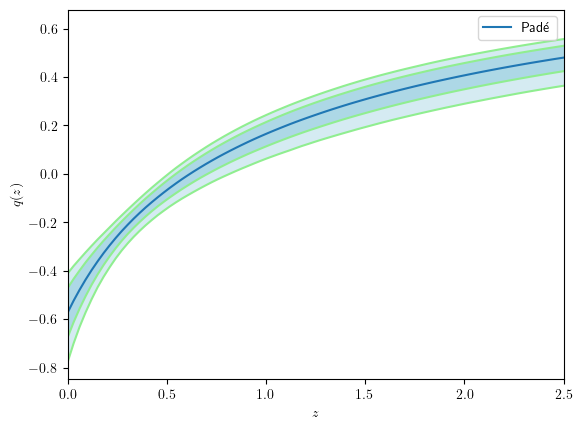

In [86]:
#plt.figure(figsize=(4.3,3.2))
pl.plot(zvec,qzmat[:,1],label='Padé')
#pl.plot(zvec,np.ones_like(zvec),label=r'Flat $\Lambda$CDM')
pl.fill_between(zvec,qzmat[:,4],qzmat[:,5], facecolor='lightblue',alpha=.5)
pl.fill_between(zvec,qzmat[:,2],qzmat[:,3],facecolor='lightblue')
pl.plot(zvec,qzmat[:,2],color='lightgreen')
pl.plot(zvec,qzmat[:,3],color='lightgreen')
pl.plot(zvec,qzmat[:,4],color='lightgreen')
pl.plot(zvec,qzmat[:,5],color='lightgreen')
#pl.plot(zvec, np.zeros_like(zvec), color='k',ls='--', linewidth=0.5)
pl.xlabel('$z$')
pl.ylabel('$q(z)$')
pl.xlim(0,2.5)
#pl.ylim(0,5)
pl.legend()
pl.savefig('./fig/qz'+prefix+'.pdf')
pl.show()

In [87]:
etamat = []
for i in range(nz):
    etamat.append(fzsamp(eta,zvec[i],samples))

etamat = np.array(etamat)
print(np.shape(etamat))

np.savetxt('./data/eta'+prefix+'.txt',etamat)

(100, 6)


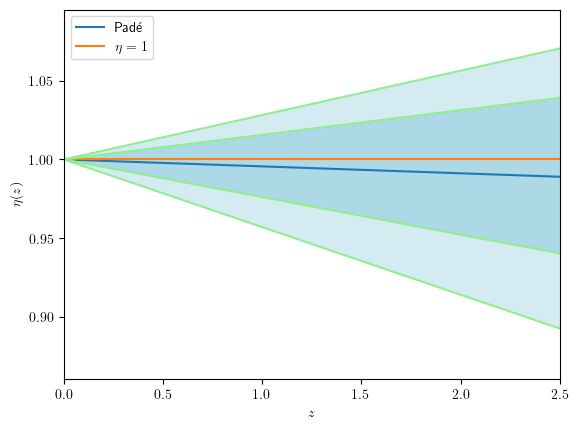

In [88]:
#plt.figure(figsize=(4.3,3.2))
pl.plot(zvec,etamat[:,1],label='Padé')
pl.plot(zvec,np.ones_like(zvec),label=r'$\eta=1$')
pl.fill_between(zvec,etamat[:,4],etamat[:,5], facecolor='lightblue',alpha=.5)
pl.fill_between(zvec,etamat[:,2],etamat[:,3],facecolor='lightblue')
pl.plot(zvec,etamat[:,2],color='lightgreen')
pl.plot(zvec,etamat[:,3],color='lightgreen')
pl.plot(zvec,etamat[:,4],color='lightgreen')
pl.plot(zvec,etamat[:,5],color='lightgreen')
#pl.plot(zvec, np.zeros_like(zvec), color='k',ls='--', linewidth=0.5)
pl.xlabel('$z$')
pl.ylabel(r'$\eta(z)$')
pl.xlim(0,2.5)
#pl.ylim(0,5)
pl.legend()
pl.savefig('./fig/eta'+prefix+'.pdf')
pl.show()